In [33]:
# Cell 0.1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 80)

PROCESSED = Path('../data/processed')
FIGDIR = Path('../reports/figures')
FIGDIR.mkdir(parents=True, exist_ok=True)

In [34]:
# Cell 0.2 — Load raw data
df = pd.read_csv('../data/raw/mental-health-in-tech-2016.csv')
print(df.shape)
df.head(2)

(1433, 63)


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [35]:
# Cell 0.3 — Dataset summary
print("Dataset loaded successfully.")
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")



Dataset loaded successfully.
Rows:    1,433
Columns: 63


In [36]:
# ============================================================
# Cell 0.4 — COMPLETE COLUMN INVENTORY
# ============================================================

column_inventory = pd.DataFrame({
    "column_number": range(1, len(df.columns) + 1),
    "column_name": df.columns,
    "dtype": df.dtypes.astype(str).values
})

column_inventory

,column_number,column_name,dtype
0,1,Are you self-employed?,int64
1,2,How many employees does your company or organization have?,object
2,3,Is your employer primarily a tech company/organization?,float64
3,4,Is your primary role within your company related to tech/IT?,float64
4,5,Does your employer provide mental health benefits as part of healthcare cove...,object
5,6,Do you know the options for mental health care available under your employer...,object
6,7,"Has your employer ever formally discussed mental health (for example, as par...",object
7,8,Does your employer offer resources to learn more about mental health concern...,object
8,9,Is your anonymity protected if you choose to take advantage of mental health...,object
9,10,"If a mental health issue prompted you to request a medical leave from work, ...",object


In [37]:
# ============================================================
# Cell 0.5 — DUPLICATE ROW ANALYSIS
# ============================================================
#
# Purpose:
#     Determine whether the dataset contains completely
#     duplicated observations.
#
# Duplicate observations can affect clustering because
# identical respondents effectively receive additional weight.
# ============================================================

duplicate_count = df.duplicated().sum()

print(f"Number of completely duplicated rows: {duplicate_count:,}")
print(
    f"Percentage of dataset duplicated: "
    f"{duplicate_count / len(df) * 100:.2f}%"
)

Number of completely duplicated rows: 0
Percentage of dataset duplicated: 0.00%


In [38]:
# ============================================================
# Cell 0.6 — MISSING-VALUE AUDIT
# ============================================================
#
# Purpose:
#     Calculate missing-value counts and percentages for every
#     variable.
#
# This is one of the most important parts of this project because
# missingness in this survey is often caused by branching logic.
#
# We therefore do NOT assume:
#
#     missing = random missing data
#
# Instead, this table tells us where further investigation is
# required.
# ============================================================

missing_audit = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100,
    "non_missing_count": df.notna().sum(),
    "unique_values": df.nunique(dropna=True)
})

missing_audit = (
    missing_audit
    .sort_values("missing_percentage", ascending=False)
)

missing_audit

,missing_count,missing_percentage,non_missing_count,unique_values
"If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?",1289,89.951151,144,3
"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",1229,85.764131,204,4
Is your primary role within your company related to tech/IT?,1170,81.646895,263,2
Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,1146,79.972087,287,2
"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?",1146,79.972087,287,5
"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?",1146,79.972087,287,5
"If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",1146,79.972087,287,4
Do you know local or online resources to seek help for a mental health disorder?,1146,79.972087,287,3
Do you believe your productivity is ever affected by a mental health issue?,1146,79.972087,287,4
"If maybe, what condition(s) do you believe you have?",1111,77.529658,322,99


In [39]:
# Cell 0.7 — Build column inventory with short IDs, blocks, and stats

# The raw CSV uses the long question text as column names.
# We assign stable short IDs q01..q63 in the order they appear.

short_ids = [f"q{i+1:02d}" for i in range(df.shape[1])]
col_map = pd.DataFrame({
    'short_id': short_ids,
    'column_number': range(df.shape[1]),
    'question_text': df.columns,
})
col_map['question_short'] = col_map['question_text'].str.slice(0, 70) + '...'

# Block assignment (semantic grouping)
block_assignments = {
    **{f"q{i+1:02d}": 'A_employment_context' for i in range(0, 4)},
    **{f"q{i+1:02d}": 'B_current_employer'  for i in range(4, 16)},
    **{f"q{i+1:02d}": 'C_self_employed'     for i in range(16, 24)},
    **{f"q{i+1:02d}": 'D_previous_employer' for i in range(24, 36)},
    **{f"q{i+1:02d}": 'E_interview'         for i in range(36, 40)},
    **{f"q{i+1:02d}": 'F_stigma_career'     for i in range(40, 45)},
    **{f"q{i+1:02d}": 'G_mh_history'        for i in range(45, 53)},
    **{f"q{i+1:02d}": 'H_work_interference' for i in range(53, 55)},
    **{f"q{i+1:02d}": 'I_demographics'      for i in range(55, 63)},
}
col_map['block'] = col_map['short_id'].map(block_assignments)

# Per-column statistics
stats = []
for sid, qtext in zip(col_map['short_id'], col_map['question_text']):
    s = df[qtext]
    vc = s.value_counts(dropna=True)
    stats.append({
        'short_id': sid,
        'dtype': str(s.dtype),
        'n_missing': int(s.isnull().sum()),
        'pct_missing': round(s.isnull().mean() * 100, 2),
        'n_unique': int(s.nunique(dropna=True)),
        'top_category': vc.index[0] if len(vc) else None,
        'top_category_pct': round(vc.iloc[0] / s.notnull().sum() * 100, 2) if len(vc) else None,
    })
stats_df = pd.DataFrame(stats)

col_inventory = col_map.merge(stats_df, on='short_id')
col_inventory.to_csv(PROCESSED / 'column_inventory.csv', index=False)
col_inventory[['short_id','block','n_missing','pct_missing','n_unique','top_category','top_category_pct']].head(20)

,short_id,block,n_missing,pct_missing,n_unique,top_category,top_category_pct
0,q01,A_employment_context,0,0.00,2,0,79.97
1,q02,A_employment_context,287,20.03,6,26-100,25.48
2,q03,A_employment_context,287,20.03,2,1.0,77.05
3,q04,A_employment_context,1170,81.65,2,1.0,94.30
4,q05,B_current_employer,287,20.03,4,Yes,46.34
5,q06,B_current_employer,420,29.31,3,No,34.95
6,q07,B_current_employer,287,20.03,3,No,70.94
7,q08,B_current_employer,287,20.03,3,No,46.34
8,q09,B_current_employer,287,20.03,3,I don't know,64.75
9,q10,B_current_employer,287,20.03,6,Somewhat easy,24.52


In [40]:
# Cell 0.8 — Inventory summary by block

col_inventory.groupby('block').agg(
    n_cols=('short_id','count'),
    mean_missing_pct=('pct_missing','mean'),
    max_missing_pct=('pct_missing','max'),
    mean_unique=('n_unique','mean'),
).round(2)

,n_cols,mean_missing_pct,max_missing_pct,mean_unique
block,,,,
A_employment_context,4,30.43,81.65,3.00
B_current_employer,12,20.80,29.31,3.25
C_self_employed,8,81.94,89.95,3.75
D_previous_employer,12,10.81,11.79,3.50
E_interview,4,11.25,23.59,542.75
F_stigma_career,5,12.07,54.15,4.60
G_mh_history,8,23.53,77.53,44.50
H_work_interference,2,0.00,0.00,5.00
I_demographics,8,10.28,41.38,73.88


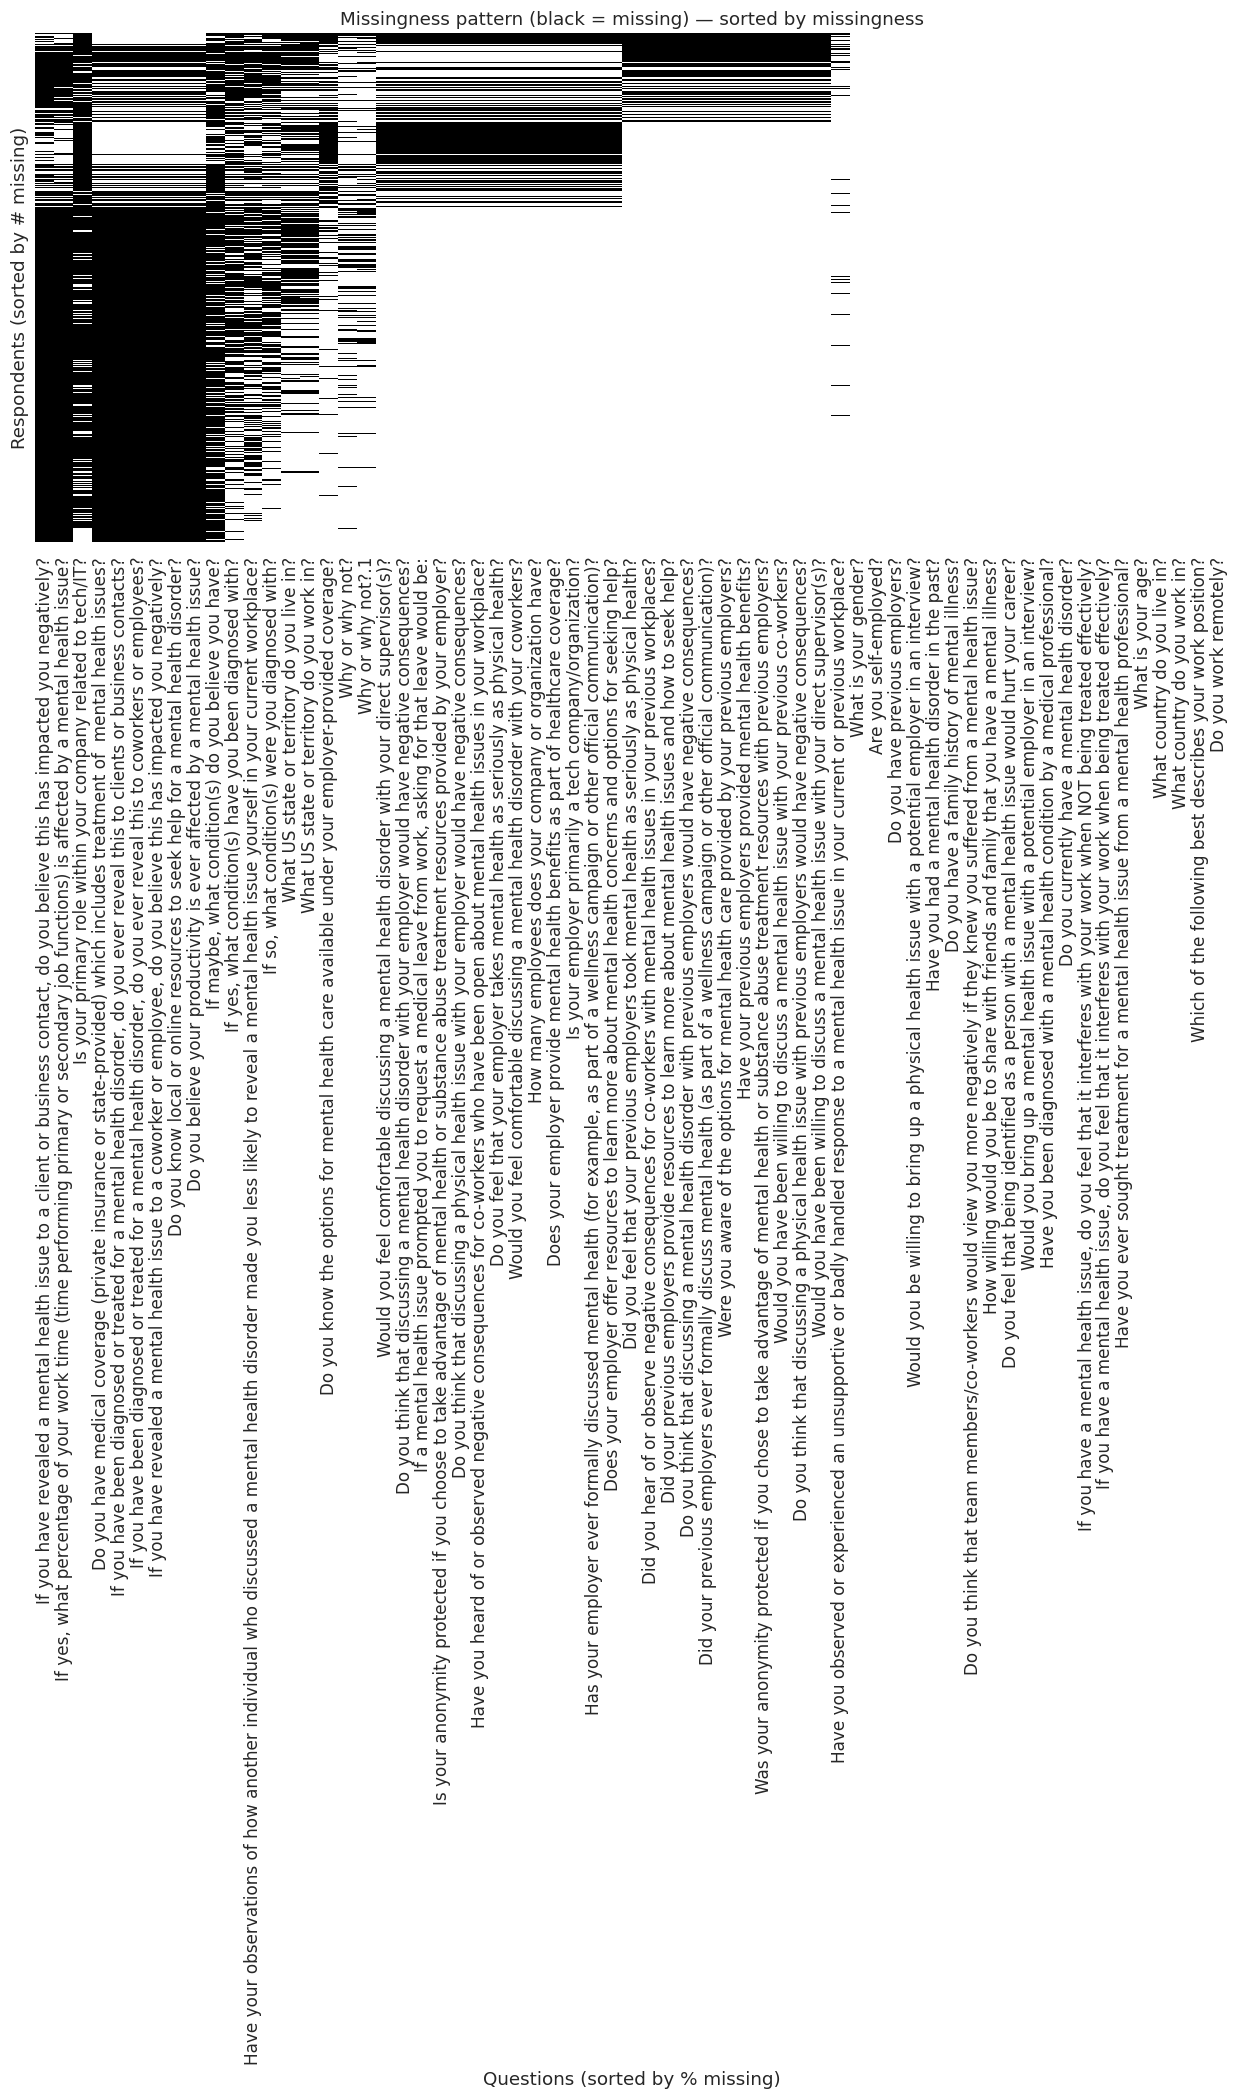

In [41]:
# Cell 0.9 — Missingness heatmap (respondents × questions, sorted)

fig, ax = plt.subplots(figsize=(14, 6))
miss = df.isnull()
# sort columns by missingness pct, rows by total missing
col_order = miss.mean().sort_values(ascending=False).index
row_order = miss.sum(axis=1).sort_values(ascending=False).index
sns.heatmap(miss.loc[row_order, col_order], cbar=False, cmap='gray_r', ax=ax,
            yticklabels=False)
ax.set_title('Missingness pattern (black = missing) — sorted by missingness')
ax.set_xlabel('Questions (sorted by % missing)')
ax.set_ylabel('Respondents (sorted by # missing)')
plt.tight_layout()
plt.savefig(FIGDIR / 'missingness_heatmap.png', bbox_inches='tight')
plt.show()

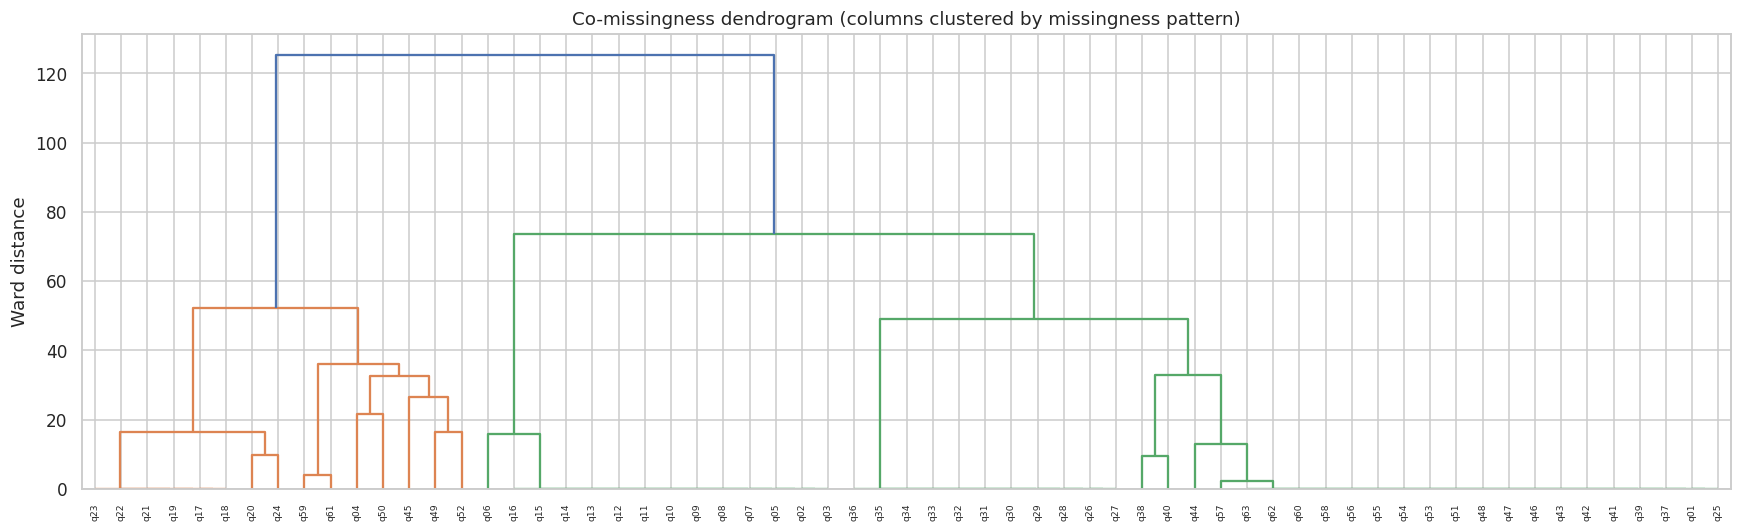

In [42]:
# Cell 1.0 — Hierarchical clustering of columns by missingness pattern
miss = df.isnull().astype(int)
Z = linkage(miss.T, method='ward')

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, labels=col_inventory['short_id'].tolist(), leaf_rotation=90, ax=ax)
ax.set_title('Co-missingness dendrogram (columns clustered by missingness pattern)')
ax.set_ylabel('Ward distance')
plt.tight_layout()
plt.savefig(FIGDIR / 'comissingness_dendrogram.png', bbox_inches='tight')
plt.show()

### Missingness Heatmap & Co-missingness Dendrogram – Interpretation

I created these two plots to understand the structure of missing data in the survey.

**Missingness Heatmap**  
The heatmap displays all 1,433 respondents (rows) against the 63 questions (columns). Both axes are sorted: columns by percentage of missing values (highest on the left) and rows by the total number of missing answers (highest at the top). Black cells represent missing values, white cells represent observed values.

Looking at the plot, I can see large solid black vertical blocks on the far left. These correspond to the questions with the highest missingness, mainly:
- the self-employed-only questions (Block C: q17–q24),
- some highly conditional questions such as diagnosis details and US state fields.

The upper part of the heatmap is much darker overall. These rows are respondents who skipped many questions — predominantly the self-employed participants. As we move to the right side of the plot the colour becomes progressively lighter, showing that the remaining questions (especially stigma, mental-health history, work interference and demographics) were answered by almost everyone.

This clear block structure confirms that the missingness is **structural (MNAR)** and not random.

**Co-missingness Dendrogram**  
To examine the missingness patterns more precisely, I clustered the 63 questions using hierarchical clustering (Ward linkage) based on how similarly they are missing across respondents.

The dendrogram shows three distinct groups that are also colour-coded in the plot:

- **Orange cluster (left side)**: This group contains the questions with the strongest co-missingness. It is dominated by the self-employed block (q17–q24) together with several conditional questions (e.g. q04, q19, q20, q21, q22, q23, q45, q49, q50, q52). These questions tend to be missing for the same respondents.

- **Green cluster (middle)**: This cluster mainly groups the current-employer questions (Block B: q05–q16). They are missing together because they were only shown to people who are not self-employed.

- **Green cluster (right side)**: This is the largest group and contains the questions with the lowest missingness. It includes most of the previous-employer questions (Block D), the stigma and career questions (Block F), mental-health history (Block G), work interference (Block H), and the demographic variables (Block I). These questions were answered by nearly all participants.

**Conclusion**  
Both plots show that missingness is highly structured and driven by two survey-logic flags: “Are you self-employed?” and “Do you have previous employers?”.  

Since the case study focuses on employees working inside technology companies, I decided to exclude the self-employed respondents. Removing them eliminates the large orange cluster and most of the structural missingness visible in the heatmap, resulting in a much cleaner dataset that better represents the target population of the HR programme.

In [43]:
# Cell 1.1 — Cluster membership (cut at 3 clusters)
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(Z, t=3, criterion='maxclust')
col_inventory['missingness_cluster'] = clusters
col_inventory.groupby('missingness_cluster')['block'].value_counts()

missingness_cluster  block               
1                    C_self_employed          8
                     G_mh_history             3
                     I_demographics           2
                     A_employment_context     1
                     F_stigma_career          1
2                    B_current_employer      12
                     A_employment_context     2
3                    D_previous_employer     12
                     I_demographics           6
                     G_mh_history             5
                     E_interview              4
                     F_stigma_career          4
                     H_work_interference      2
                     A_employment_context     1
Name: count, dtype: int64

In [44]:
# Cell 1.2 — Sensitivity check: cut at k=4
clusters4 = fcluster(Z, t=4, criterion='maxclust')
col_inventory['missingness_cluster_k4'] = clusters4
print(col_inventory.groupby('missingness_cluster_k4')['block'].value_counts())

missingness_cluster_k4  block               
1                       C_self_employed          8
2                       G_mh_history             3
                        I_demographics           2
                        A_employment_context     1
                        F_stigma_career          1
3                       B_current_employer      12
                        A_employment_context     2
4                       D_previous_employer     12
                        I_demographics           6
                        G_mh_history             5
                        E_interview              4
                        F_stigma_career          4
                        H_work_interference      2
                        A_employment_context     1
Name: count, dtype: int64


In [45]:
# Cell 1.3 — Verify the three-layer routing structure
cluster2_cols = col_inventory.loc[col_inventory['missingness_cluster_k4']==2,
                                  'question_text'].tolist()
cluster1_cols = col_inventory.loc[col_inventory['missingness_cluster_k4']==1,
                                  'question_text'].tolist()

df['_c1_missing'] = df[cluster1_cols].isnull().all(axis=1)
df['_c2_missing'] = df[cluster2_cols].isnull().all(axis=1)

# Cluster 2 should be missing for ALL cluster-1-missing respondents (employed),
# plus some self-employed who didn't trigger the follow-up.
print("Cluster 2 missing given Cluster 1 missing:")
print(pd.crosstab(df['_c1_missing'], df['_c2_missing']))

# Among self-employed only, what triggers Cluster 2?
self_emp = df[df['Are you self-employed?']==1]
print("\nAmong self-employed, Cluster 2 missing vs MH history:")
print(pd.crosstab(self_emp['_c2_missing'],
                  self_emp['Have you had a mental health disorder in the past?']))

Cluster 2 missing given Cluster 1 missing:
_c2_missing  False  True 
_c1_missing              
False          252     35
True          1054     92

Among self-employed, Cluster 2 missing vs MH history:
Have you had a mental health disorder in the past?  Maybe  No  Yes
_c2_missing                                                       
False                                                  56  45  151
True                                                    6  27    2


In [46]:
# Cell 1.4 — Why do 92 employed respondents skip Cluster 2?
cluster2_cols = col_inventory.loc[col_inventory['missingness_cluster_k4']==2,
                                  'question_text'].tolist()
df['_c2_missing'] = df[cluster2_cols].isnull().all(axis=1)
df['_blockD_missing'] = df[col_inventory.loc[col_inventory['block']=='D_previous_employer',
                                              'question_text'].tolist()].isnull().all(axis=1)

# Among employed only
emp = df[df['Are you self-employed?']==0]
print("Among employed (n=1,146):")
print(pd.crosstab(emp['_c2_missing'], emp['_blockD_missing']))

# Which specific Cluster 2 columns drive the 92?
c2_cols = col_inventory.loc[col_inventory['missingness_cluster_k4']==2,
                            ['question_text','block','short_id']]
print("\nCluster 2 composition:")
print(c2_cols)

# Missingness rate of each Cluster 2 column among employed
print("\nPer-column missingness among employed:")
print(df[df['Are you self-employed?']==0][cluster2_cols].isnull().mean().round(3))

Among employed (n=1,146):
_blockD_missing  False
_c2_missing           
False             1054
True                92

Cluster 2 composition:
                                                                      question_text  \
3                      Is your primary role within your company related to tech/IT?   
44  Have your observations of how another individual who discussed a mental heal...   
48                          If yes, what condition(s) have you been diagnosed with?   
49                             If maybe, what condition(s) do you believe you have?   
51                                If so, what condition(s) were you diagnosed with?   
58                                       What US state or territory do you live in?   
60                                       What US state or territory do you work in?   

                   block short_id  
3   A_employment_context      q04  
44       F_stigma_career      q45  
48          G_mh_history      q49  
49          G_mh_

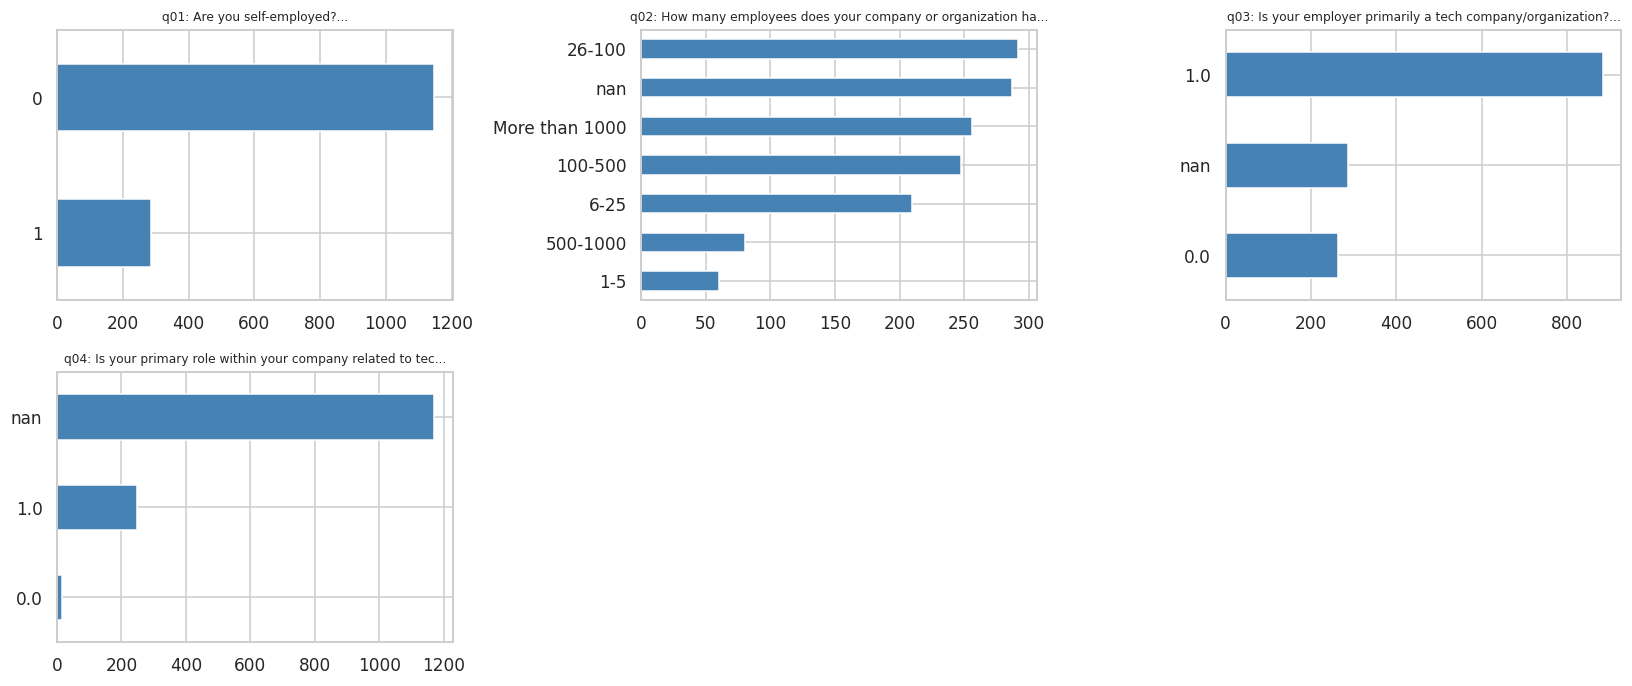

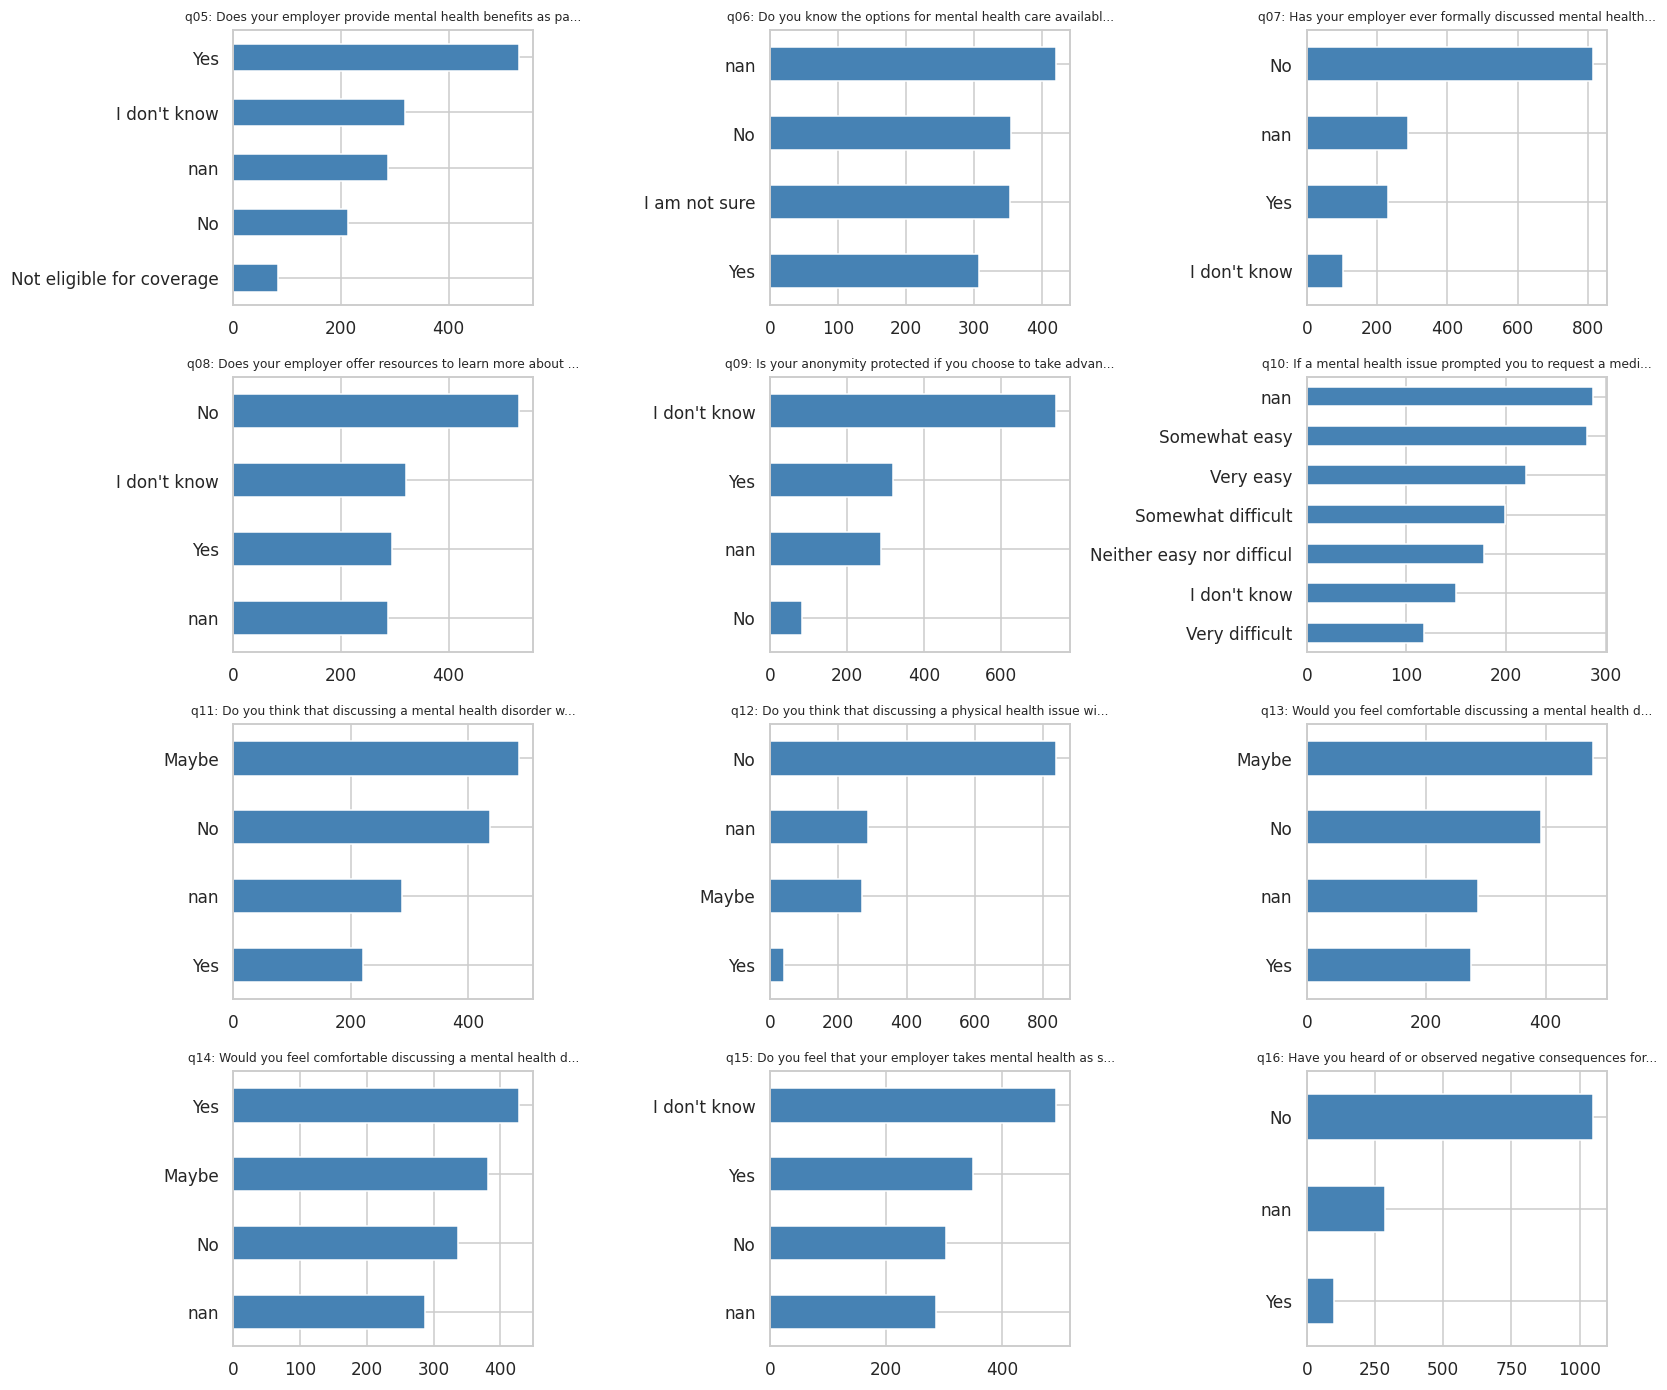

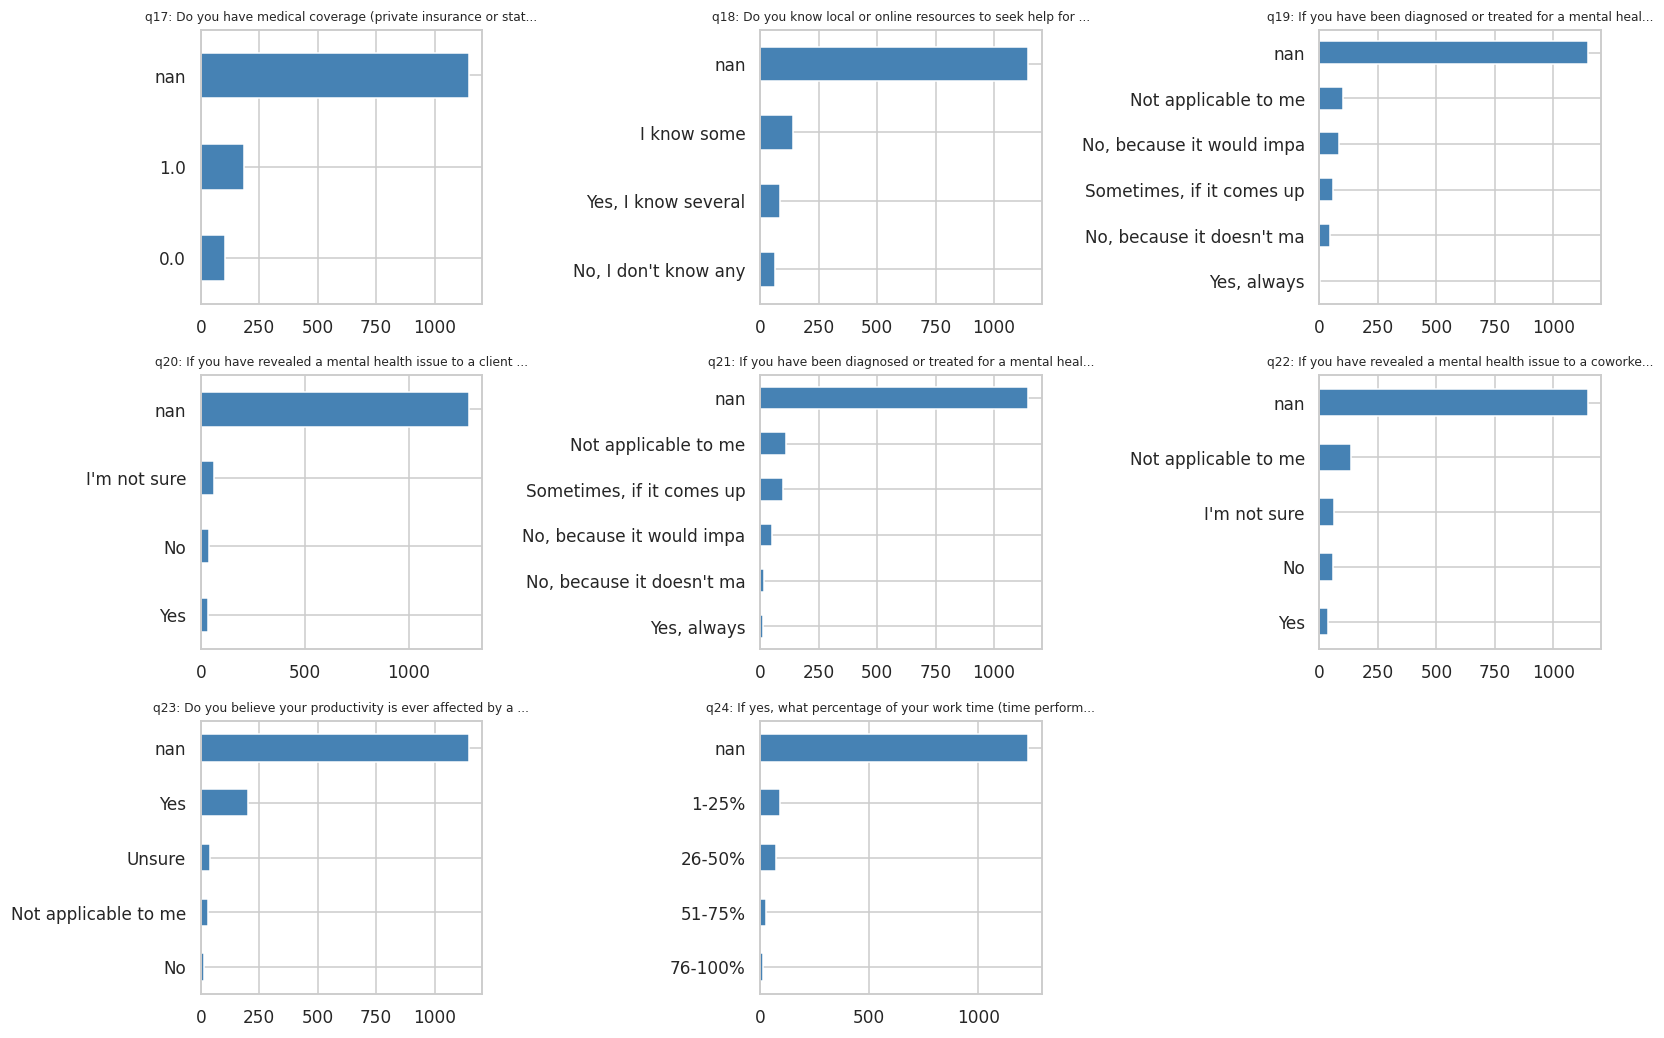

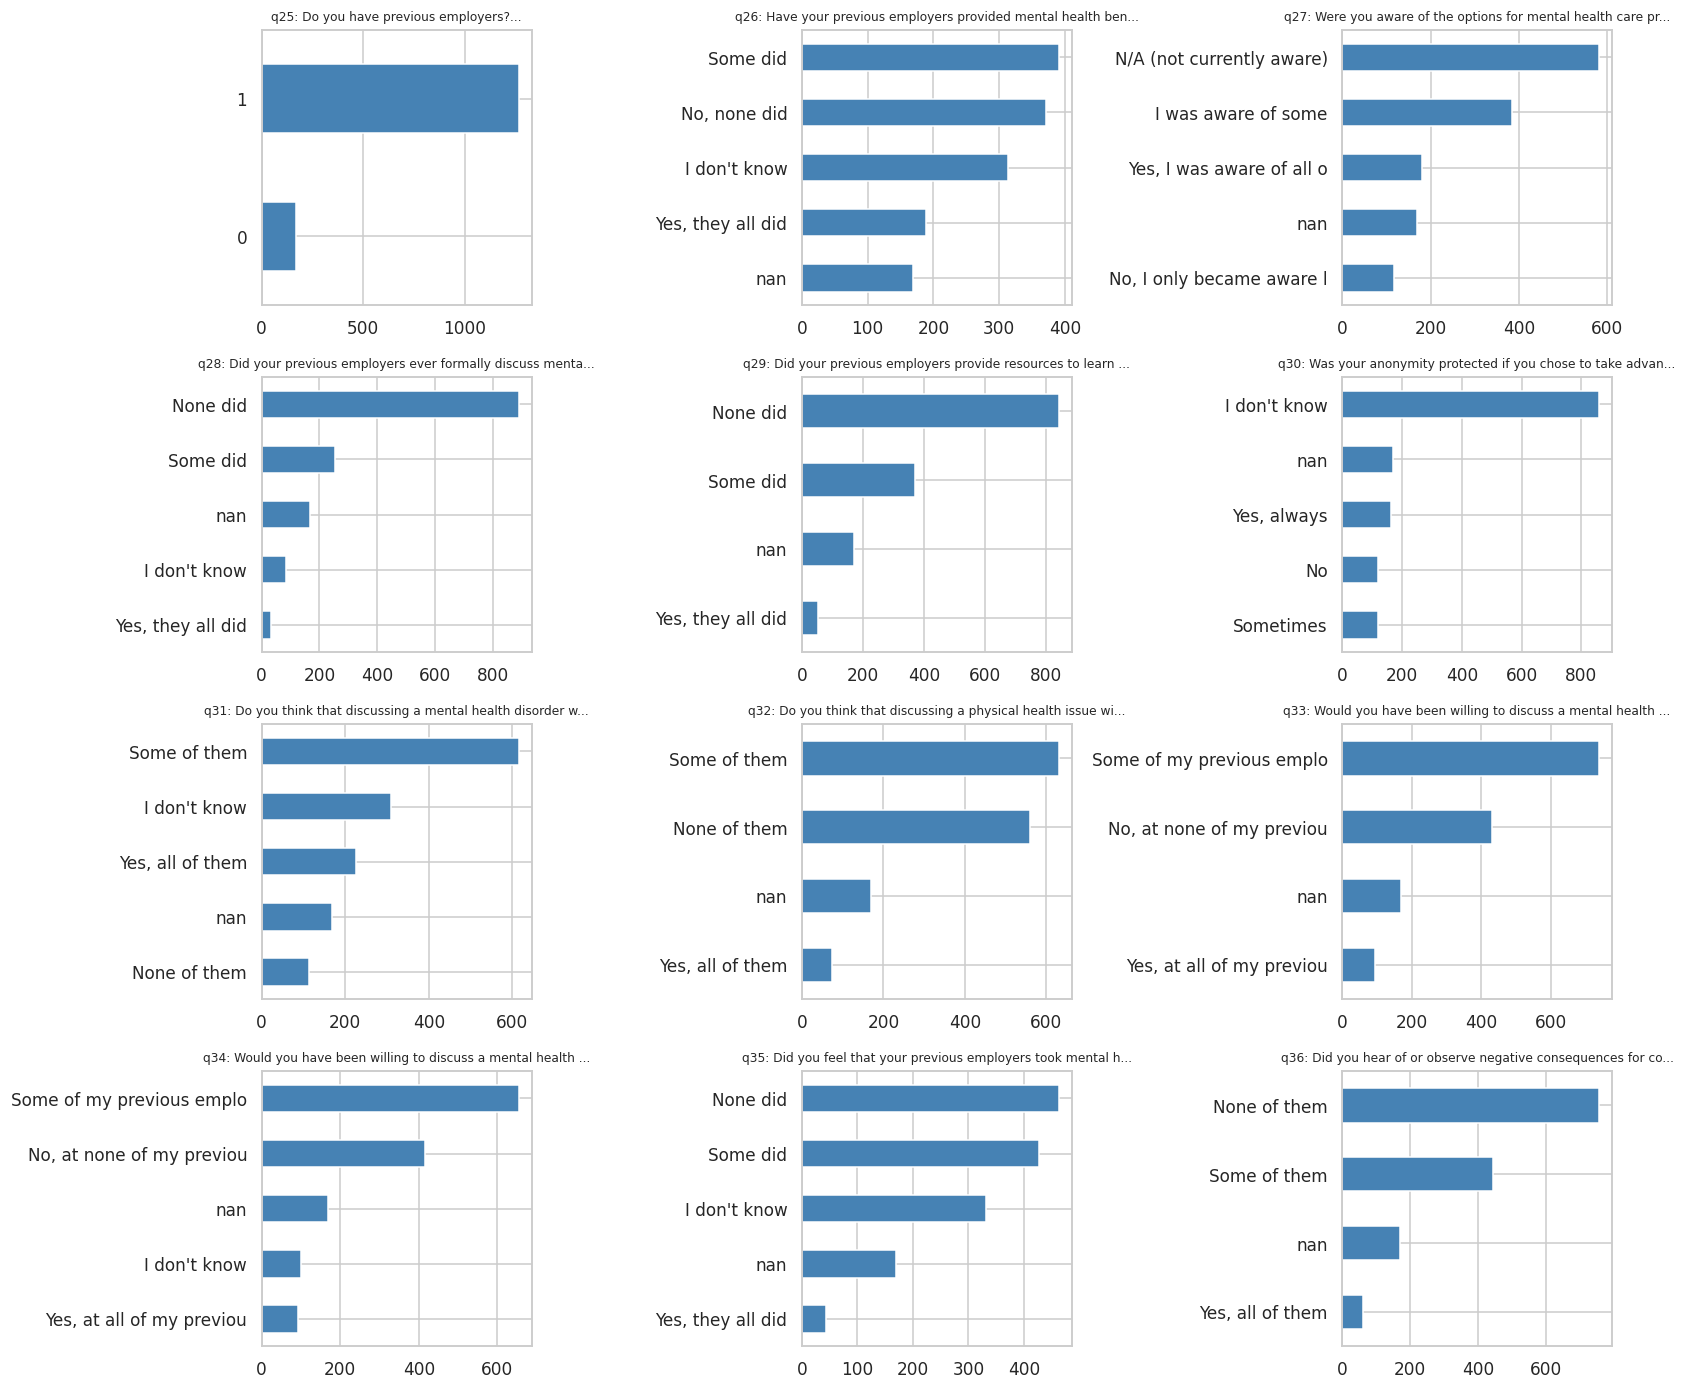

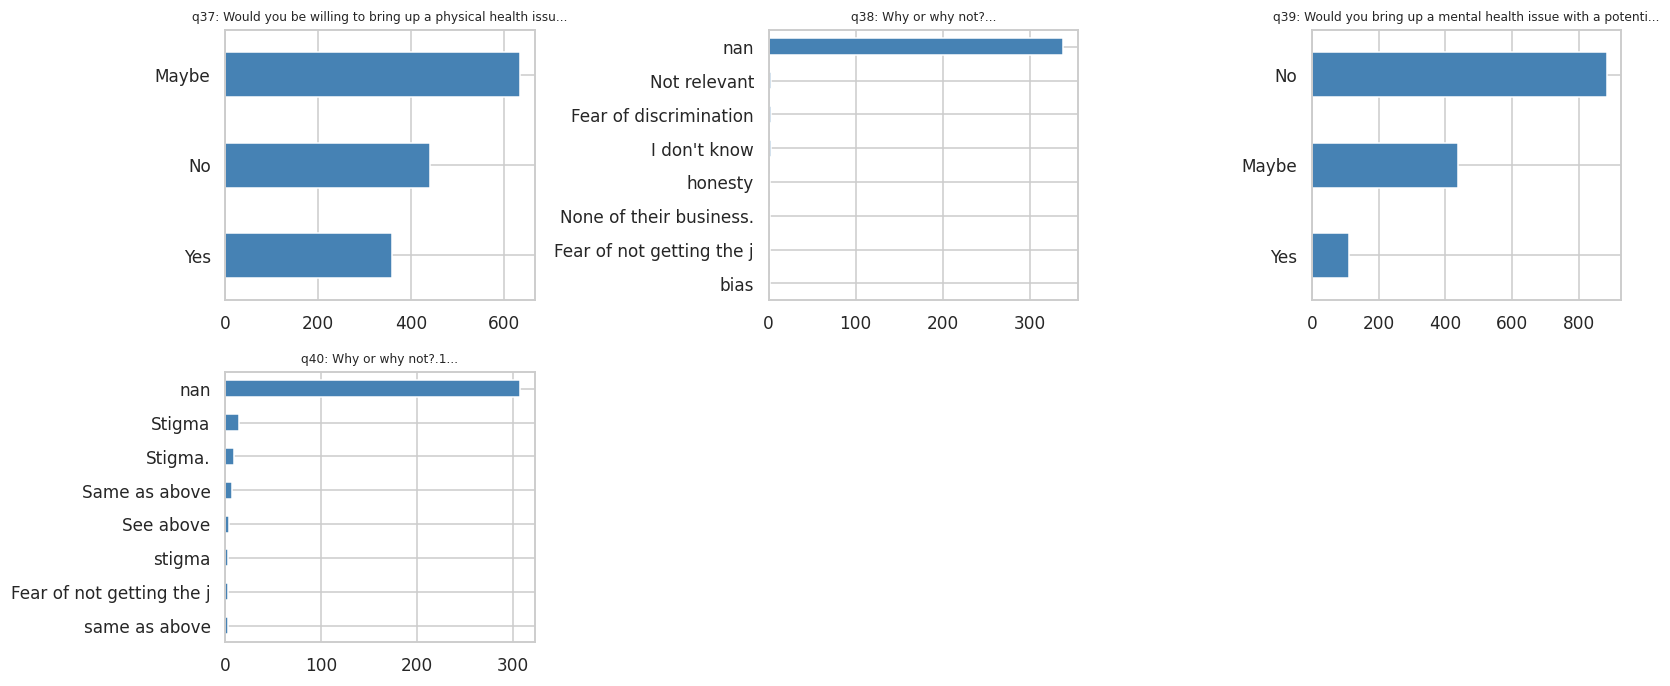

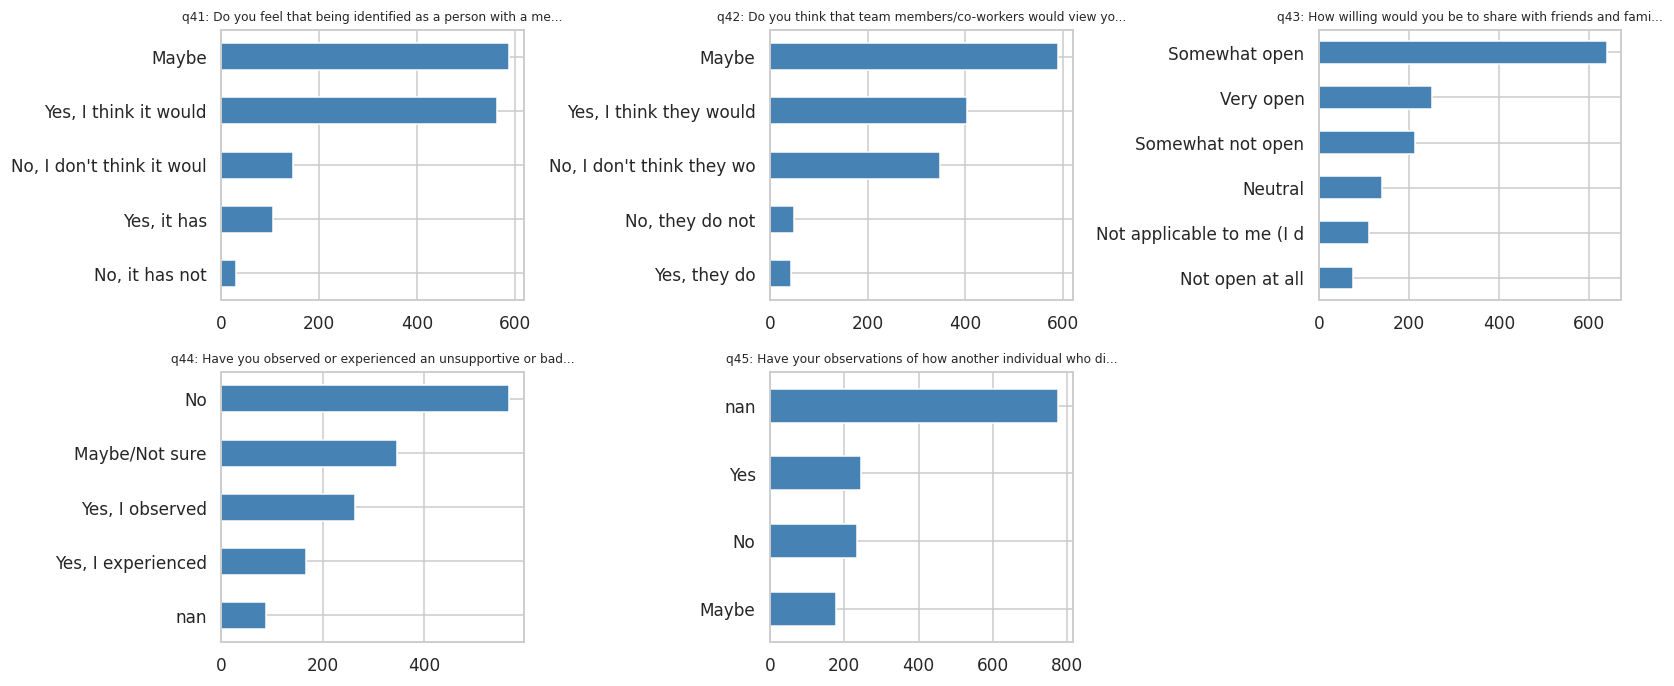

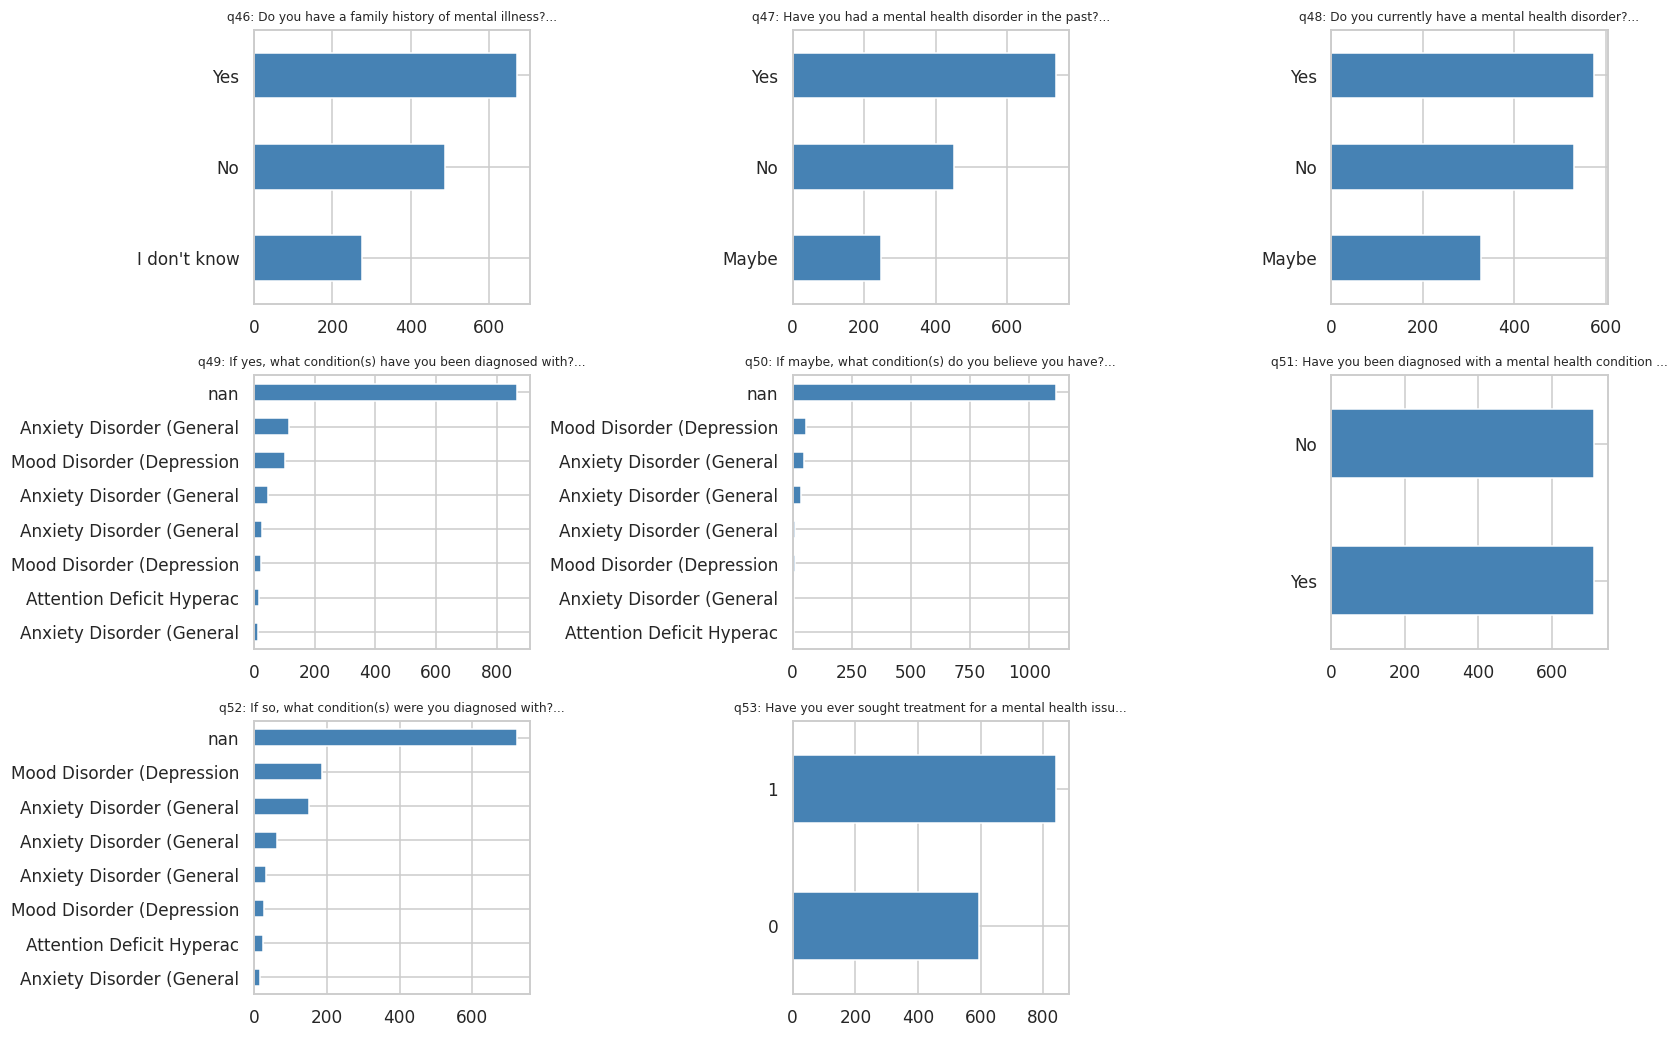

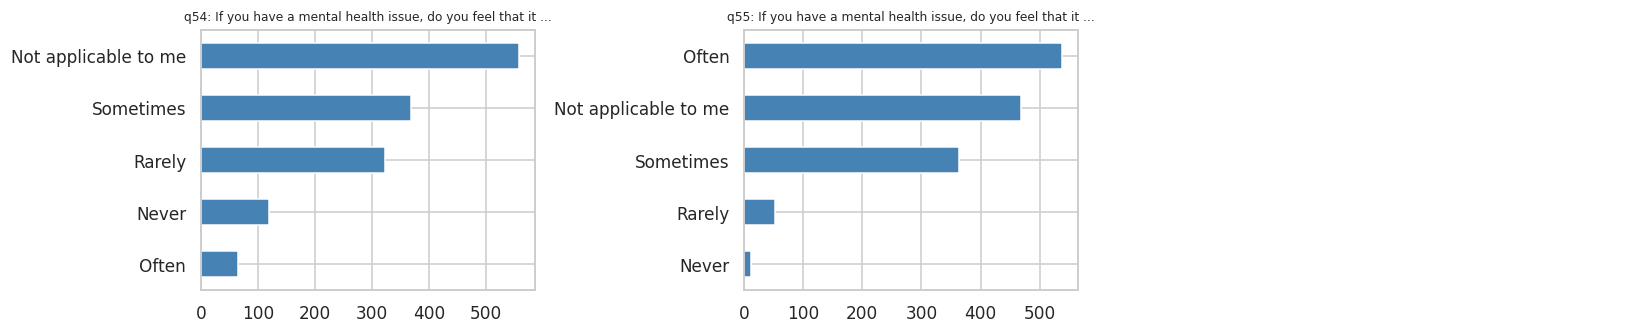

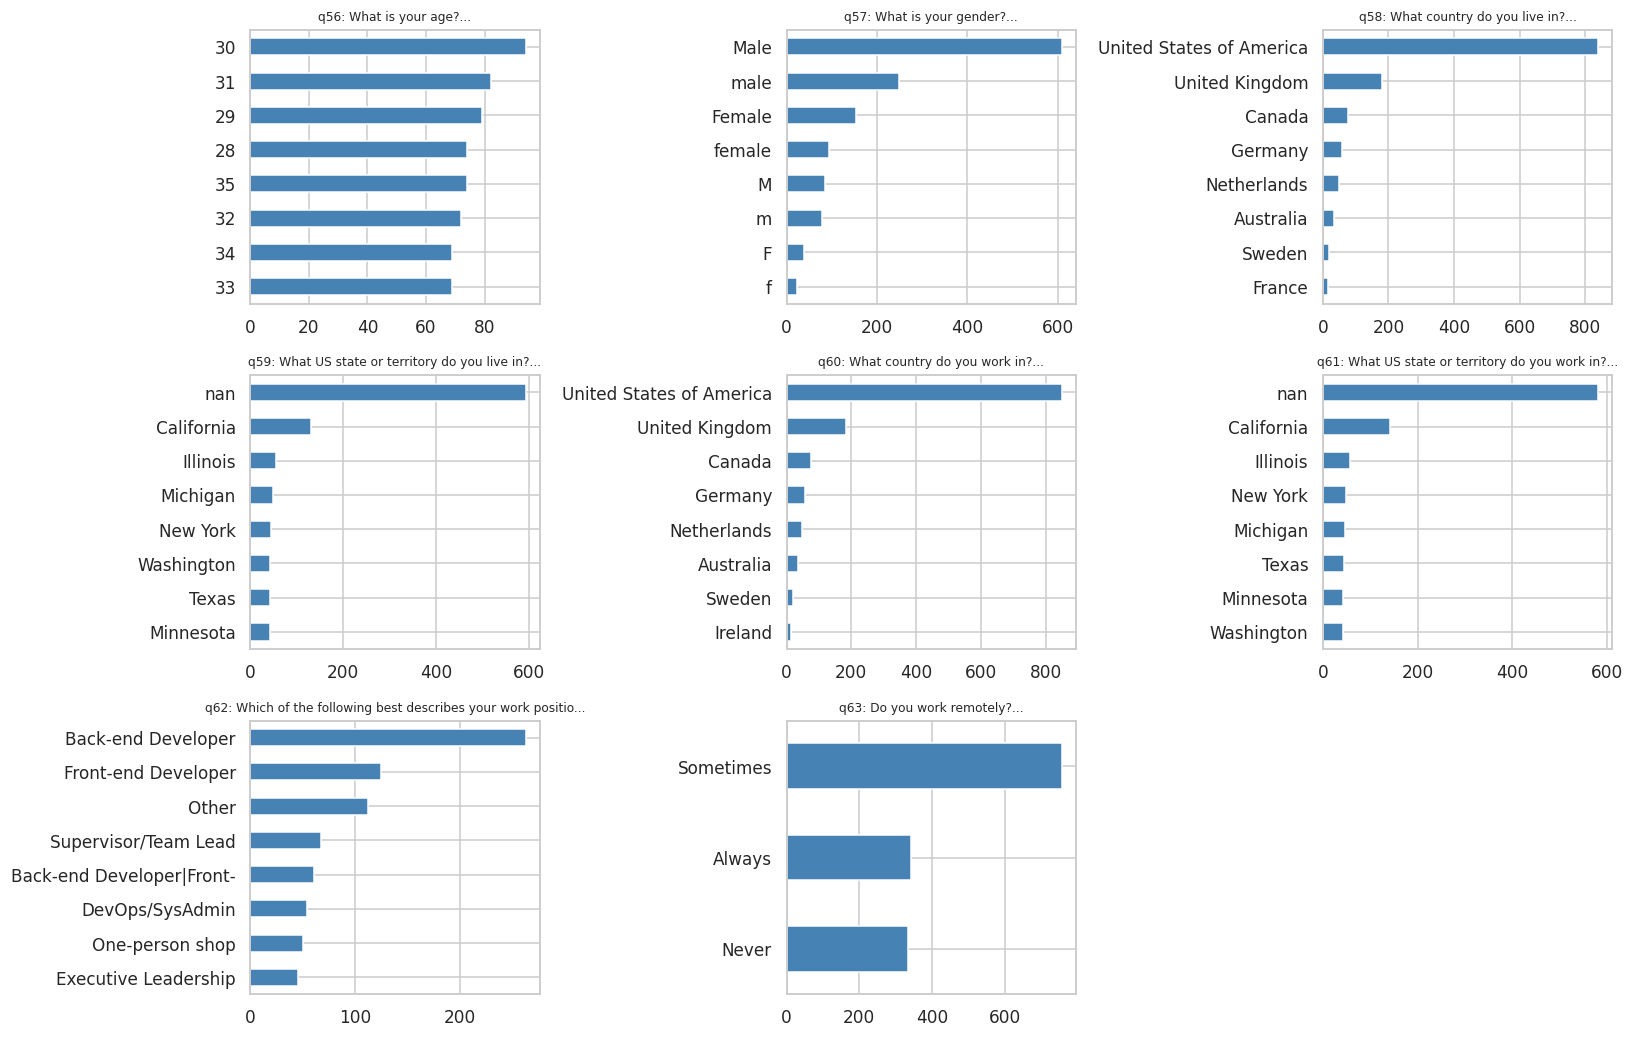

In [47]:
# Cell 1.5 — Helper to plot a block of categorical columns
def plot_block(block_name, ncols=3):
    cols = col_inventory.loc[col_inventory['block'] == block_name, 'question_text'].tolist()
    ids  = col_inventory.loc[col_inventory['block'] == block_name, 'short_id'].tolist()
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows))
    axes = np.array(axes).reshape(-1)
    for ax, cid, q in zip(axes, ids, cols):
        vc = df[q].value_counts(dropna=False).head(8)
        vc.index = [str(i)[:25] for i in vc.index]
        vc.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'{cid}: {q[:55]}...', fontsize=8)
        ax.invert_yaxis()
    for ax in axes[len(cols):]:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIGDIR / f'univariate_{block_name}.png', bbox_inches='tight')
    plt.show()

for b in ['A_employment_context','B_current_employer','C_self_employed',
          'D_previous_employer','E_interview','F_stigma_career',
          'G_mh_history','H_work_interference','I_demographics']:
    plot_block(b)

In [48]:
# Cell 1.6 — Self-employed explains Block B/C missingness
block_b_cols = col_inventory.loc[col_inventory['block']=='B_current_employer','question_text'].tolist()
block_c_cols = col_inventory.loc[col_inventory['block']=='C_self_employed','question_text'].tolist()

df['_blockB_all_missing'] = df[block_b_cols].isnull().all(axis=1)
df['_blockC_all_missing'] = df[block_c_cols].isnull().all(axis=1)

print("Block B missing vs self-employed:")
print(pd.crosstab(df['Are you self-employed?'], df['_blockB_all_missing']))
print("\nBlock C missing vs self-employed:")
print(pd.crosstab(df['Are you self-employed?'], df['_blockC_all_missing']))

Block B missing vs self-employed:
_blockB_all_missing     False  True 
Are you self-employed?              
0                        1146      0
1                           0    287

Block C missing vs self-employed:
_blockC_all_missing     False  True 
Are you self-employed?              
0                           0   1146
1                         287      0


In [49]:
# Cell 1.7 — Previous-employer flag explains Block D missingness
df['_blockD_all_missing'] = df[col_inventory.loc[col_inventory['block']=='D_previous_employer','question_text'].tolist()].isnull().all(axis=1)
print(pd.crosstab(df['Do you have previous employers?'], df['_blockD_all_missing']))

_blockD_all_missing              False
Do you have previous employers?       
0                                  169
1                                 1264


In [50]:
# Cell 1.7b — Per-column missingness in Block D, split by q24
block_d_df = col_inventory.loc[
    col_inventory['block'] == 'D_previous_employer',
    ['short_id', 'question_text']
]

rows = []
for _, r in block_d_df.iterrows():
    q = r['question_text']
    rows.append({
        'short_id': r['short_id'],
        'question_short': q[:60],
        'missing_pct_no_prev': round(
            df.loc[df['Do you have previous employers?'] == 0, q].isnull().mean() * 100, 1),
        'missing_pct_has_prev': round(
            df.loc[df['Do you have previous employers?'] == 1, q].isnull().mean() * 100, 1),
    })

block_d_missing = pd.DataFrame(rows)
block_d_missing['gap'] = (block_d_missing['missing_pct_no_prev']
                          - block_d_missing['missing_pct_has_prev'])
block_d_missing.sort_values('gap', ascending=False).reset_index(drop=True)

,short_id,question_short,missing_pct_no_prev,missing_pct_has_prev,gap
0,q26,Have your previous employers provided mental health benefits,100.0,0.0,100.0
1,q27,Were you aware of the options for mental health care provide,100.0,0.0,100.0
2,q28,Did your previous employers ever formally discuss mental hea,100.0,0.0,100.0
3,q29,Did your previous employers provide resources to learn more,100.0,0.0,100.0
4,q33,Would you have been willing to discuss a mental health issue,100.0,0.0,100.0
5,q30,Was your anonymity protected if you chose to take advantage,100.0,0.0,100.0
6,q31,Do you think that discussing a mental health disorder with p,100.0,0.0,100.0
7,q32,Do you think that discussing a physical health issue with pr,100.0,0.0,100.0
8,q35,Did you feel that your previous employers took mental health,100.0,0.0,100.0
9,q34,Would you have been willing to discuss a mental health issue,100.0,0.0,100.0


In [51]:
# Cell 1.8 — Compute Cramér's V for all categorical pairs
from scipy.stats import chi2_contingency
import itertools

def cramers_v(x, y):
    """Compute Cramér's V between two categorical series.
    Returns NaN if either series has <2 categories after dropping NaN."""
    ct = pd.crosstab(x, y)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = ct.shape
    # Bias correction (Bergsma 2013)
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2corr / denom)

# Only compute for low-cardinality categorical columns (exclude free text)
cat_cols = col_inventory.loc[
    (col_inventory['dtype'] == 'object') &
    (col_inventory['n_unique'] < 30),
    'question_text'
].tolist()

# Map question_text -> short_id
text_to_sid = dict(zip(col_inventory['question_text'], col_inventory['short_id']))

# Compute pairwise Cramér's V
results = []
for a, b in itertools.combinations(cat_cols, 2):
    v = cramers_v(df[a], df[b])
    if not np.isnan(v):
        results.append({
            'var1': text_to_sid[a],
            'var2': text_to_sid[b],
            'var1_text': a[:80],
            'var2_text': b[:80],
            'cramers_v': round(v, 4),
        })

cramers = pd.DataFrame(results).sort_values('cramers_v', ascending=False).reset_index(drop=True)
cramers['flagged'] = cramers['cramers_v'] >= 0.85
cramers.to_csv(PROCESSED / 'cramers_v_flagged_pairs.csv', index=False)
print(f"Computed {len(cramers)} pairs; {cramers['flagged'].sum()} flagged at V >= 0.85")
cramers.head(10)

Computed 898 pairs; 0 flagged at V >= 0.85


,var1,var2,var1_text,var2_text,cramers_v,flagged
0,q47,q51,Have you had a mental health disorder in the past?,Have you been diagnosed with a mental health condition by a medical professi...,0.7521,False
1,q19,q51,"If you have been diagnosed or treated for a mental health disorder, do you e...",Have you been diagnosed with a mental health condition by a medical professi...,0.6970,False
2,q51,q54,Have you been diagnosed with a mental health condition by a medical professi...,"If you have a mental health issue, do you feel that it interferes with your ...",0.6947,False
3,q21,q51,"If you have been diagnosed or treated for a mental health disorder, do you e...",Have you been diagnosed with a mental health condition by a medical professi...,0.6705,False
4,q48,q51,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professi...,0.6585,False
5,q51,q55,Have you been diagnosed with a mental health condition by a medical professi...,"If you have a mental health issue, do you feel that it interferes with your ...",0.6461,False
6,q33,q34,Would you have been willing to discuss a mental health issue with your previ...,Would you have been willing to discuss a mental health issue with your direc...,0.5852,False
7,q28,q29,Did your previous employers ever formally discuss mental health (as part of ...,Did your previous employers provide resources to learn more about mental hea...,0.5807,False
8,q47,q48,Have you had a mental health disorder in the past?,Do you currently have a mental health disorder?,0.5703,False
9,q19,q21,"If you have been diagnosed or treated for a mental health disorder, do you e...","If you have been diagnosed or treated for a mental health disorder, do you e...",0.5538,False


### Cramér’s V Analysis – Interpretation

I computed Cramér’s V for all pairs of categorical variables to detect strong associations.

- 898 pairs were evaluated.
- **No pair reached the threshold of 0.85**, so there is no severe collinearity that would require immediate variable removal.
- The strongest associations (V = 0.55–0.75) are concentrated in the mental-health history block (q47, q48, q51, q54, q55). This is expected: past disorder, current disorder, professional diagnosis and work interference are conceptually related.
- Moderate associations also appear between disclosure-related questions (q19 ↔ q21) and between previous-employer support questions (q28 ↔ q29, q33 ↔ q34).

**Decision:**  
I will keep all variables for the first clustering iteration. In Notebook 3 I may still decide to reduce a few highly related pairs if the clustering results become unstable or hard to interpret.

In [52]:
# Cell 1.9 — Top 20 Cramér's V pairs
top20 = cramers.head(20).copy()

# Attach block info for easier reading
sid_to_block = dict(zip(col_inventory['short_id'], col_inventory['block']))
top20['var1_block'] = top20['var1'].map(sid_to_block)
top20['var2_block'] = top20['var2'].map(sid_to_block)

top20[['var1', 'var1_block', 'var2', 'var2_block', 'cramers_v', 'flagged']]

,var1,var1_block,var2,var2_block,cramers_v,flagged
0,q47,G_mh_history,q51,G_mh_history,0.7521,False
1,q19,C_self_employed,q51,G_mh_history,0.6970,False
2,q51,G_mh_history,q54,H_work_interference,0.6947,False
3,q21,C_self_employed,q51,G_mh_history,0.6705,False
4,q48,G_mh_history,q51,G_mh_history,0.6585,False
5,q51,G_mh_history,q55,H_work_interference,0.6461,False
6,q33,D_previous_employer,q34,D_previous_employer,0.5852,False
7,q28,D_previous_employer,q29,D_previous_employer,0.5807,False
8,q47,G_mh_history,q48,G_mh_history,0.5703,False
9,q19,C_self_employed,q21,C_self_employed,0.5538,False


### Cramér’s V Results with Block Information

I examined the 20 strongest associations and mapped them to the semantic blocks.

- The highest values (0.65–0.75) are concentrated inside the Mental Health History block (G) and between Block G and Work Interference (H). This is expected and indicates a coherent construct rather than problematic redundancy.
- Moderate associations (0.48–0.59) appear within the Previous Employer block (D) and the Current Employer block (B), showing internal consistency in disclosure comfort and employer support questions.
- Several high associations involve questions from the Self-employed block (C). These will become irrelevant once I exclude self-employed respondents.

**Decision:**  
Because no pair exceeds 0.85, I will retain all variables for the first version of the clustering feature set. I will re-evaluate redundancy after filtering out self-employed respondents and after encoding.

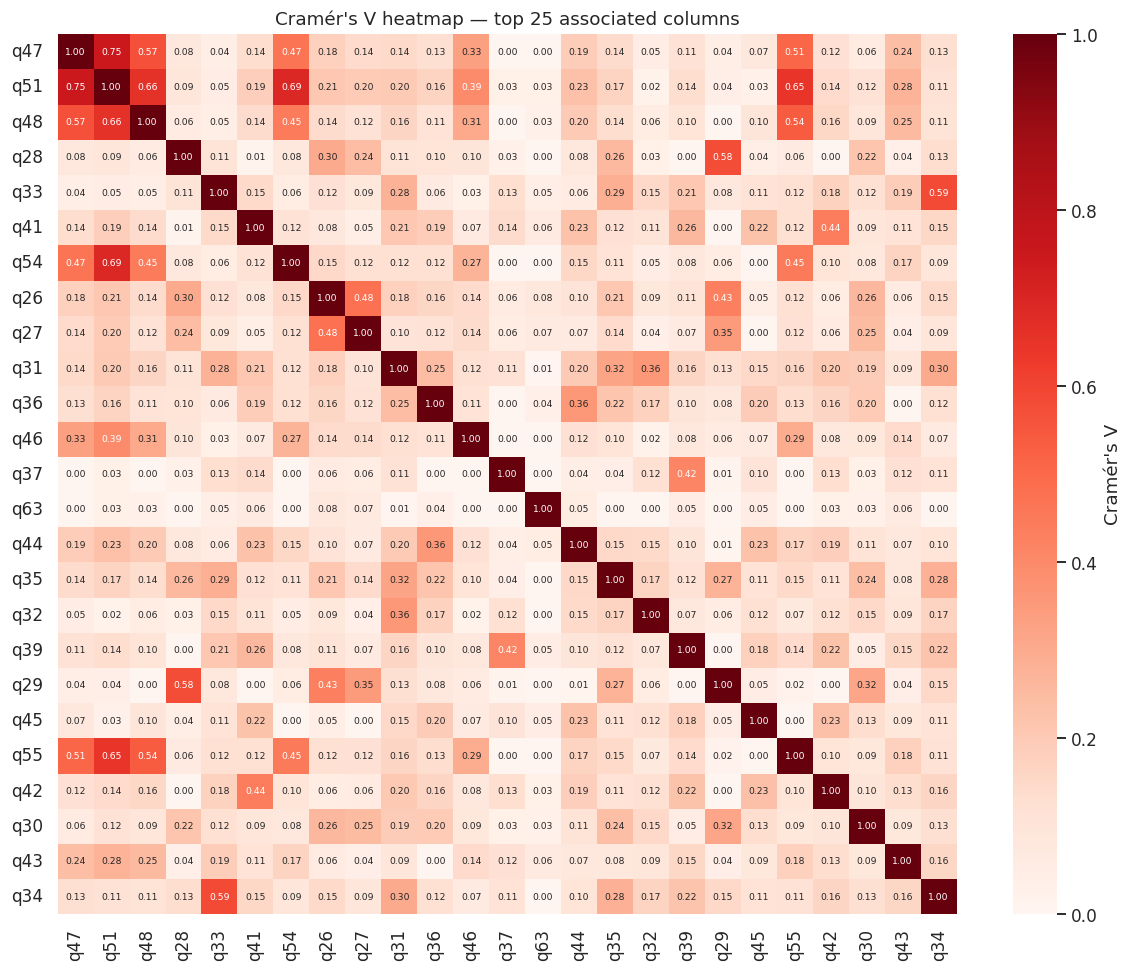

In [53]:
# Cell 2.0 — Cramér's V heatmap (top 25 columns by mean association)
# Pivot to matrix form for heatmap
def get_v(a, b):
    row = cramers[((cramers['var1']==a) & (cramers['var2']==b)) |
                  ((cramers['var1']==b) & (cramers['var2']==a))]
    return row['cramers_v'].iloc[0] if len(row) else np.nan

# Pick the 25 columns with highest mean association
sid_counts = pd.concat([cramers['var1'], cramers['var2']]).value_counts()
top_sids = sid_counts.head(25).index.tolist()

matrix = pd.DataFrame(index=top_sids, columns=top_sids, dtype=float)
for a in top_sids:
    for b in top_sids:
        if a == b:
            matrix.loc[a, b] = 1.0
        elif pd.isna(matrix.loc[a, b]):
            v = get_v(a, b)
            matrix.loc[a, b] = v
            matrix.loc[b, a] = v

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(matrix.astype(float), cmap='Reds', vmin=0, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 6}, ax=ax,
            cbar_kws={'label': "Cramér's V"})
ax.set_title("Cramér's V heatmap — top 25 associated columns")
plt.tight_layout()
plt.savefig(FIGDIR / 'cramers_v_heatmap.png', bbox_inches='tight')
plt.show()

### Cramér’s V Heatmap – Interpretation

The heatmap displays the 25 questions with the strongest mutual associations.

- The darkest block in the top-left corner is formed by **q47, q48 and q51** (past disorder, current disorder, professional diagnosis). These three variables are conceptually related and form a coherent mental-health-status construct.
- **q54** and **q55** (work interference) show clear associations with the mental-health-status questions, which is expected and useful for clustering.
- Within the previous-employer block, pairs such as q28–q29 and q33–q34 show moderate consistency.
- Most other associations are weak (light colours), indicating that the majority of questions contribute relatively independent information.

Because no association exceeds 0.85, I will retain all of these variables for the initial clustering feature set. After removing self-employed respondents I will re-check the associations.

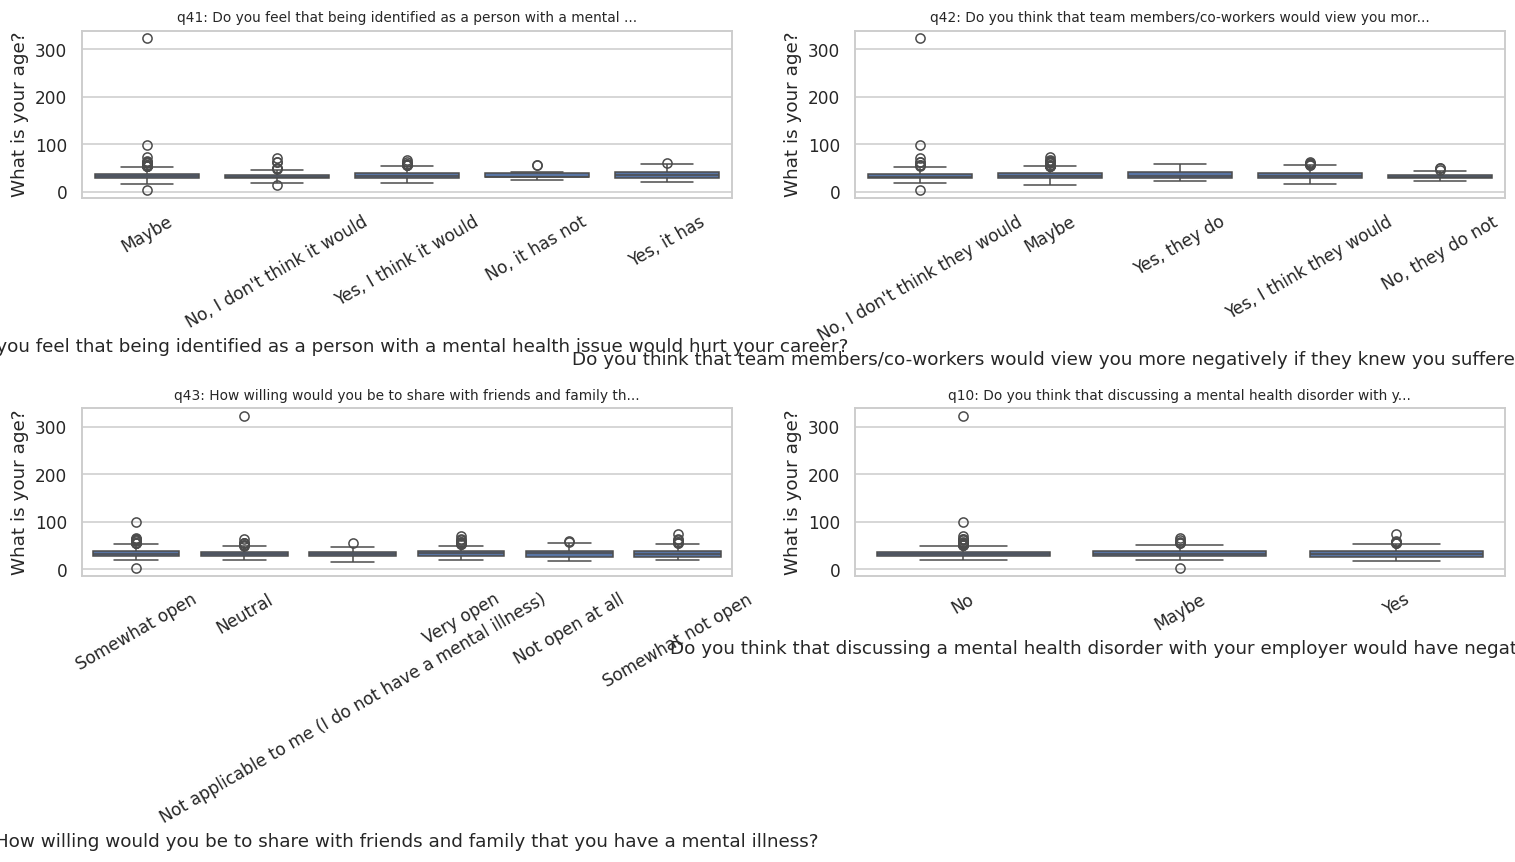

In [54]:
# Cell 2.1 — Age boxplots by stigma response
stigma_qs = {
    'q41': 'Do you feel that being identified as a person with a mental health issue would hurt your career?',
    'q42': 'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?',
    'q43': 'How willing would you be to share with friends and family that you have a mental illness?',
    'q10': 'Do you think that discussing a mental health disorder with your employer would have negative consequences?',
}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (sid, q) in zip(axes.ravel(), stigma_qs.items()):
    sns.boxplot(data=df, x=q, y='What is your age?', ax=ax)
    ax.set_title(f'{sid}: {q[:60]}...', fontsize=9)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGDIR / 'age_vs_stigma.png', bbox_inches='tight')
plt.show()

**Interpretation of Age vs. Stigma Boxplots**

These four boxplots show the distribution of age for different answer categories of key stigma-related questions.

### Main observations

**1. Age is very similar across all answer groups**
- In all four plots the median age (horizontal line inside the box) stays roughly between **30 and 35 years**.
- The boxes (middle 50% of respondents) largely overlap.
- This means **age does not strongly differentiate** how people answer these stigma questions.

**2. Outliers are present but not systematic**
- There are a few very high ages (above 100, even one around 300). These are almost certainly data-entry errors or joke answers and should be cleaned in preprocessing.
- The extreme outliers appear in several categories, so they are not linked to a specific opinion.

**3. Slight tendencies (but weak)**
- **q41 (career would be hurt)**: People who say “Yes, it has” or “Yes, I think it would” have a similar age profile to those who say “No”.
- **q42 (coworkers would view negatively)**: Again, almost no visible age difference.
- **q43 (willingness to share with friends/family)**: Slightly wider spread in some categories, but medians remain close.
- **q10 (negative consequences with employer)**: Same pattern — medians are nearly identical for “No”, “Maybe” and “Yes”.

### Conclusion

Age has **only a very weak relationship** with perceived stigma and disclosure comfort.  
Younger and older respondents (within the normal working-age range) give similar answers on these questions.


I examined the relationship between age and four key stigma-related questions using boxplots.

- The median age is approximately 30–35 years in almost every answer category.
- The interquartile ranges overlap heavily, indicating that age does not strongly influence how respondents perceive career harm, coworker judgement, or willingness to disclose.
- A small number of extreme outliers (ages > 100) are visible; these are likely data errors and will be removed during preprocessing.

**Conclusion:** Age shows only a very weak association with stigma perceptions. It is therefore more useful as a contextual / demographic variable than as a primary clustering feature.


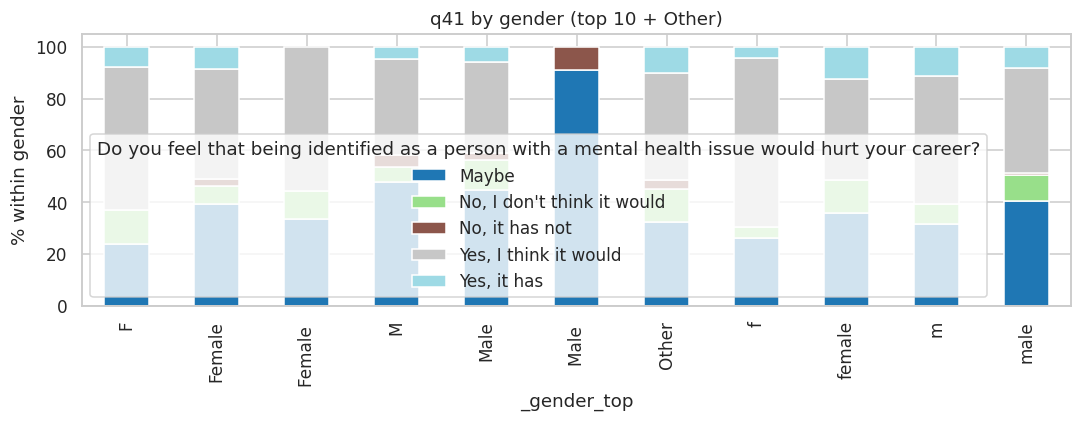

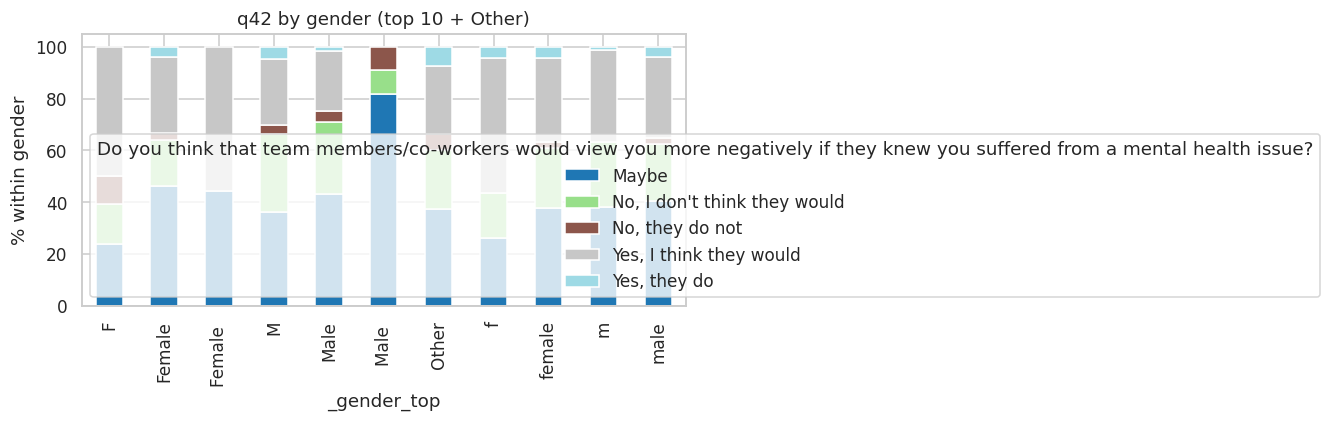

In [55]:
# Cell 2.2 — Gender (top 10) vs. stigma

top_genders = df['What is your gender?'].value_counts().head(10).index
df['_gender_top'] = np.where(df['What is your gender?'].isin(top_genders),
                             df['What is your gender?'], 'Other')
for sid, q in list(stigma_qs.items())[:2]:
    ct = pd.crosstab(df['_gender_top'], df[q], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(10,4), colormap='tab20')
    plt.title(f'{sid} by gender (top 10 + Other)')
    plt.ylabel('% within gender')
    plt.tight_layout()
    plt.savefig(FIGDIR / f'gender_vs_{sid}.png', bbox_inches='tight')
    plt.show()

**Interpretation of Gender vs. Stigma Plots**

These stacked bar charts show how answers to q41 and q42 are distributed across the most frequent gender labels.

### Main problems visible in the plots

1. **Gender is extremely messy**
   - The same gender appears under many different spellings:
     - Male / male / M / m
     - Female / female / F / f
   - This makes the x-axis hard to read and splits the same group into many small bars.

2. **No clear, strong gender pattern**
   - In both q41 and q42 the largest segment in almost every bar is the grey one (“Yes, I think it would” / “Yes, I think they would”).
   - The proportion of “Maybe” and “No” answers looks roughly similar across the bigger groups (Male/male and Female/female).
   - Because the categories are fragmented, it is difficult to draw reliable conclusions.

3. **“Other” and rare labels**
   - The “Other” group and some low-frequency labels show more variation, but the sample sizes are small, so these differences are not trustworthy.

### Conclusion

Gender in its raw form is **not usable** for analysis. The high number of inconsistent spellings (70 unique values in the original data) creates noise and makes visual comparison unreliable.

### What you should do next

In Notebook 2 i must consolidate gender into a small number of clean categories, for example:

- Male
- Female
- Non-binary / Other
- Prefer not to say

Only after this cleaning will gender vs. stigma plots become meaningful.


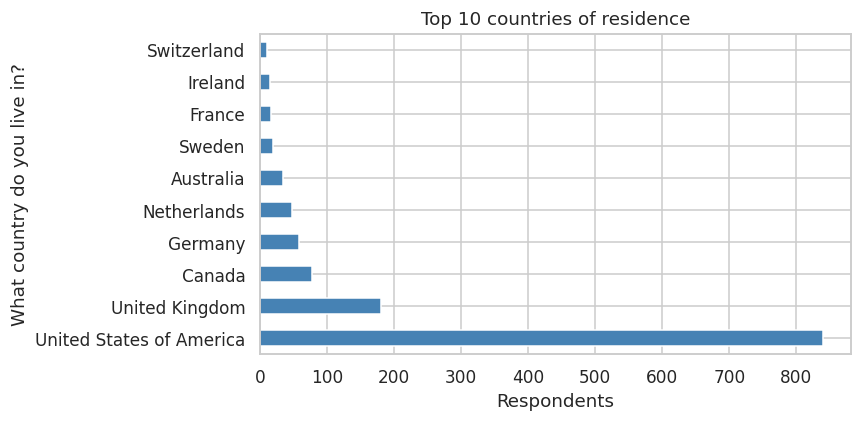

US share: 58.6%


In [56]:
# Cell 2.3 — Country distribution
top_countries = df['What country do you live in?'].value_counts().head(10)
top_countries.plot(kind='barh', figsize=(8,4), color='steelblue')
plt.title('Top 10 countries of residence')
plt.xlabel('Respondents')
plt.tight_layout()
plt.savefig(FIGDIR / 'top_countries.png', bbox_inches='tight')
plt.show()
print(f"US share: {(df['What country do you live in?']=='United States of America').mean()*100:.1f}%")

**Interpretation of Country Distribution**

The bar chart shows the 10 most common countries of residence.

### Key findings

- **United States of America** is by far the dominant country (~840 respondents, **58.6%** of the sample).
- **United Kingdom** is a distant second (~180 respondents).
- **Canada**, **Germany**, **Netherlands**, **Australia**, **Sweden**, **France**, **Ireland** and **Switzerland** follow with much smaller numbers.
- All remaining countries together make up a relatively small share.

### Implications for your analysis

1. **Strong geographic bias**  
   The dataset is heavily US-centric. Results will mainly reflect the experiences of people working in the United States (and to a lesser extent the UK and other Western countries).

2. **Limited generalisability**  
   Findings about stigma, employer support, or disclosure comfort may not fully apply to tech workers in Asia, Latin America, Africa, or Eastern Europe.

3. **Practical decision for preprocessing**  
   Because many countries have very few respondents, it is better to consolidate them. A useful grouping for later analysis is:

   - United States
   - United Kingdom
   - Canada
   - Germany
   - Other Europe
   - Other / Rest of World



In [57]:
# Cell 2.4 — Flag columns by role
role = []
for _, row in col_inventory.iterrows():
    sid, block, nuniq, toppct = row['short_id'], row['block'], row['n_unique'], row['top_category_pct']
    if nuniq >= 50:
        r = 'identifier_or_freetext'   # exclude
    elif toppct is not None and toppct >= 90:
        r = 'near_constant'            # exclude
    elif block in ['A_employment_context','I_demographics']:
        r = 'context'                  # stratify, don't cluster on
    elif block == 'C_self_employed':
        r = 'sparse_subgroup'          # exclude or separate analysis
    else:
        r = 'clustering_candidate'
    role.append(r)
col_inventory['role'] = role

print(col_inventory.groupby('role')['short_id'].count())
col_inventory.loc[col_inventory['role']=='clustering_candidate',
                  ['short_id','block','question_short','n_unique','top_category_pct']]

role
clustering_candidate      37
context                    6
identifier_or_freetext    10
near_constant              2
sparse_subgroup            8
Name: short_id, dtype: int64


,short_id,block,question_short,n_unique,top_category_pct
4,q05,B_current_employer,Does your employer provide mental health benefits as part of healthcar...,4,46.34
5,q06,B_current_employer,Do you know the options for mental health care available under your em...,3,34.95
6,q07,B_current_employer,"Has your employer ever formally discussed mental health (for example, ...",3,70.94
7,q08,B_current_employer,Does your employer offer resources to learn more about mental health c...,3,46.34
8,q09,B_current_employer,Is your anonymity protected if you choose to take advantage of mental ...,3,64.75
9,q10,B_current_employer,If a mental health issue prompted you to request a medical leave from ...,6,24.52
10,q11,B_current_employer,Do you think that discussing a mental health disorder with your employ...,3,42.50
11,q12,B_current_employer,Do you think that discussing a physical health issue with your employe...,3,73.04
12,q13,B_current_employer,Would you feel comfortable discussing a mental health disorder with yo...,3,41.80
13,q14,B_current_employer,Would you feel comfortable discussing a mental health disorder with yo...,3,37.35


### Role Assignment: Interpretation and Decisions

The role partition produces 37 clustering candidates, 6 context columns,
10 identifier/free-text columns, 2 near-constant columns, and 8 sparse-
subgroup columns. This is a healthy, well-balanced split.

**Key decisions:**

1. **Clustering candidates (37 → 36 after reclassification).** These span
   six blocks and cover the four constructs identified as strongest in
   the Cramér's V analysis: disclosure comfort, stigma/career impact,
   mental-health history, and work interference. All have 2–6 categories
   and none exceed the 90% top-category threshold.

2. **q25 reclassified to context.** The previous-employer flag is a
   routing variable, not an attitude variable. Keeping it as a clustering
   candidate risks producing clusters defined by employment history rather
   than mental-health attitudes. It is retained as a stratification
   variable and can be used post-hoc to characterise clusters.

3. **Context columns (6) retained separately.** Demographics (age, gender,
   country, position, remote work) will be used to describe clusters after
   the fact, not as clustering inputs. This avoids clusters driven by
   nationality or gender.

4. **Identifier/free-text columns (10) excluded from clustering.** High-
   cardinality fields (gender with 70 values, country with 53, diagnosis
   lists with 99–128) cannot be one-hot encoded without producing sparse
   noise columns. Some will be revisited in Notebook 3 for targeted
   feature engineering (e.g., keyword flags for stigma in free text).

5. **Near-constant columns (2) dropped.** No discriminative power.

6. **Sparse-subgroup columns (8) dropped after filtering.** Block C is
   100% missing once the 287 self-employed respondents are removed.

The role column is now the operational driver for Notebook 2 and
Notebook 3. After filtering, the clustering feature set will contain
approximately 30–36 strong candidate columns, which is appropriate for
the planned dimensionality reduction and clustering steps.

In [58]:
# Cell 2.5 — Top tokens in free-text columns
from collections import Counter
import re

def top_tokens(series, n=20):
    text = ' '.join(series.dropna().astype(str).str.lower())
    tokens = re.findall(r"[a-z']{3,}", text)
    stop = set("the and for you not are with have that this but can will your they would "
               "there what why yes because from about them their been has had were was "
               "when who how all any out our get more some very just dont didn doesnt "
               "into than then also its it's i'm i've".split())
    return Counter(t for t in tokens if t not in stop).most_common(n)

for q in ['Why or why not?', 'Why or why not?.1']:
    print(f"\n=== {q} ===")
    for tok, cnt in top_tokens(df[q]):
        print(f"  {tok:>15}: {cnt}")


=== Why or why not? ===
              job: 256
           health: 189
            issue: 174
         physical: 173
             work: 168
           affect: 103
            bring: 98
          depends: 94
             want: 93
            don't: 89
        interview: 86
         wouldn't: 83
         employer: 82
           issues: 81
            might: 79
          ability: 79
             feel: 76
           impact: 75
         relevant: 68
             know: 66

=== Why or why not?.1 ===
           mental: 258
           health: 246
              job: 187
           issues: 135
            issue: 124
           stigma: 111
             same: 111
             want: 104
             work: 104
             feel: 97
        interview: 96
            don't: 94
         employer: 91
           affect: 86
         wouldn't: 84
            bring: 74
         physical: 73
             know: 71
            think: 67
            might: 63


**Interpretation of Free-Text Vocabulary**

You extracted the most frequent meaningful words from the two open-ended questions:

- **q38** → “Why or why not?” (about bringing up a **physical** health issue in an interview)
- **q40** → “Why or why not?.1” (about bringing up a **mental** health issue in an interview)

### Key observations

**1. Clear thematic difference between the two questions**

| Theme              | Physical health (q38)      | Mental health (q40)          |
|--------------------|----------------------------|------------------------------|
| Dominant words     | job, health, issue, physical, work | mental, health, job, stigma |
| Fear / risk language | affect, impact, ability   | stigma, affect, wouldn’t    |
| Decision language  | depends, want, relevant   | want, feel, think, might    |

- For **physical** health, people talk more about whether it is relevant to the job or affects their ability to work.
- For **mental** health, the word **“stigma”** appears prominently (111 times). This word is almost absent from the physical-health answers.

**2. Shared concerns**
Both questions frequently mention:
- job / work / employer / interview
- affect / impact
- want / don’t / wouldn’t

This shows that respondents are weighing career risk in both cases, but the nature of the risk feels different.

**3. Useful signal for feature engineering**
The strong presence of “stigma” only in the mental-health answers confirms that perceived stigma is a central theme.  
You can later create simple binary features such as:
- contains “stigma”
- contains “fear” / “discrimination”
- contains “relevant” / “not relevant”



In [59]:
# Cell 2.6 — Re-save column inventory with role column
# Cell 0.7 saved the inventory before roles were assigned; re-save now.
col_inventory.to_csv(PROCESSED / 'column_inventory.csv', index=False)
print(f"Saved column_inventory.csv with roles: {col_inventory.shape}")
print(col_inventory['role'].value_counts())

Saved column_inventory.csv with roles: (63, 14)
role
clustering_candidate      37
identifier_or_freetext    10
sparse_subgroup            8
context                    6
near_constant              2
Name: count, dtype: int64


In [60]:
# Cell 2.7 — Save question mapping (short_id ↔ question text ↔ block ↔ role)
mapping = col_inventory[[
    'short_id', 'column_number', 'question_text', 'question_short', 'block', 'role'
]]
mapping.to_csv(PROCESSED / 'question_mapping.csv', index=False)
print(f"Saved question_mapping.csv: {mapping.shape}")

Saved question_mapping.csv: (63, 6)


In [61]:
# Cell 2.8 — Save missingness clusters for both k=3 and k=4
miss_clusters = pd.DataFrame({
    'short_id': col_inventory['short_id'],
    'missingness_cluster_k3': col_inventory['missingness_cluster'],
    'missingness_cluster_k4': col_inventory['missingness_cluster_k4'],
})
miss_clusters.to_csv(PROCESSED / 'missingness_clusters.csv', index=False)
print(f"Saved missingness_clusters.csv: {miss_clusters.shape}")

Saved missingness_clusters.csv: (63, 3)


In [62]:
# Cell 2.9 — Save routing flags table
routing_flags = pd.DataFrame([
    {'flag': 'q01',     'question': 'Are you self-employed?',          'governs': 'Blocks B, C'},
    {'flag': 'q25',     'question': 'Do you have previous employers?', 'governs': 'Block D'},
    {'flag': 'q44',     'question': 'Observed unsupportive response?', 'governs': 'q45'},
    {'flag': 'q47',     'question': 'Currently have MH disorder?',     'governs': 'q49, q50'},
    {'flag': 'q51',     'question': 'Diagnosed by professional?',      'governs': 'q52'},
    {'flag': 'country', 'question': 'Country = United States',         'governs': 'q59, q61'},
])
routing_flags.to_csv(PROCESSED / 'routing_flags.csv', index=False)
print(f"Saved routing_flags.csv: {routing_flags.shape}")

Saved routing_flags.csv: (6, 3)


In [63]:
# Cell 2.10 — Verify all artifacts exist
import os
print("Artifacts in data/processed/:")
for f in sorted(os.listdir(PROCESSED)):
    size = (PROCESSED / f).stat().st_size
    print(f"  {f:<40} {size:>8,} bytes")

Artifacts in data/processed/:
  column_inventory.csv                       14,867 bytes
  cramers_v_flagged_pairs.csv               155,978 bytes
  missingness_clusters.csv                      559 bytes
  question_mapping.csv                       12,199 bytes
  routing_flags.csv                             268 bytes


In [64]:
import pandas as pd
from pathlib import Path

PROCESSED = Path('../data/processed')
check = pd.read_csv(PROCESSED / 'column_inventory.csv')

print("Columns:", check.columns.tolist())
print()
print("Role distribution:")
print(check['role'].value_counts())

Columns: ['short_id', 'column_number', 'question_text', 'question_short', 'block', 'dtype', 'n_missing', 'pct_missing', 'n_unique', 'top_category', 'top_category_pct', 'missingness_cluster', 'missingness_cluster_k4', 'role']

Role distribution:
role
clustering_candidate      37
identifier_or_freetext    10
sparse_subgroup            8
context                    6
near_constant              2
Name: count, dtype: int64


In [65]:
flags = pd.read_csv(PROCESSED / 'routing_flags.csv')
print(flags)

      flag                         question      governs
0      q01           Are you self-employed?  Blocks B, C
1      q25  Do you have previous employers?      Block D
2      q44  Observed unsupportive response?          q45
3      q47      Currently have MH disorder?     q49, q50
4      q51       Diagnosed by professional?          q52
5  country          Country = United States     q59, q61


In [66]:
mapping = pd.read_csv(PROCESSED / 'question_mapping.csv')
print(mapping.head())
print()
print("Shape:", mapping.shape)

  short_id  column_number  \
0      q01              0   
1      q02              1   
2      q03              2   
3      q04              3   
4      q05              4   

                                                                     question_text  \
0                                                           Are you self-employed?   
1                       How many employees does your company or organization have?   
2                          Is your employer primarily a tech company/organization?   
3                     Is your primary role within your company related to tech/IT?   
4  Does your employer provide mental health benefits as part of healthcare cove...   

                                                              question_short  \
0                                                  Are you self-employed?...   
1              How many employees does your company or organization have?...   
2                 Is your employer primarily a tech company/organiza